## Load packages and define functions

In [1]:
import pandas as pd 
import pyam
import matplotlib.pyplot as plt
from matplotlib import patches as mpatches
import pandas_indexing as pix
from pandas_indexing import isin, ismatch
import numpy as np

import os
from pathlib import Path

from fuzzywuzzy import fuzz

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import data_shepherd as ds
from data_shepherd import utils
import datatoolbox as dt

Config initialised in 0.0014 seconds


In [2]:
REMIND_RMAP = ds.utils.RegionMapping.from_model('REMIND_2.1')

## Define config

In [3]:
IKEA_ISOS = ["DEU","POL","BRA","MEX","KEN","MAR","MOZ",
             "NGA","SEN","ZAF","USA","NAM","DZA","TUR","SAU",
             "ARE","BGD","IND","IDN","PAK","VNM","GBR","AUS","CHN","JPN"]

LAM_ISOS = [
    'ABW', 'ARG', 'ATG', 'BHS', 'BLZ', 'BMU', 'BOL', 'BRA', 'BRB', 'CHL', 'COL',
    'CRI', 'CUB', 'CYM', 'DMA', 'DOM', 'ECU', 'FLK', 'GLP', 'GRD', 'GTM', 'GUF',
    'GUY', 'HND', 'HTI', 'JAM', 'KNA', 'LCA', 'MEX', 'MSR', 'MTQ','NIC', 'PAN', 'PER',
    'PRI', 'PRY', 'SLV', 'SUR', 'TCA', 'TTO', 'URY', 'VCT', 'VEN', 'VGB', 'VIR']

IKEA_ISOS.sort()

In [4]:
dscale_project = 'REMIND_fuel_mix_testing'
dscale_suffix = '17_02_2026_new_file_structure'

## Load data

In [5]:
BOX_MOUNT_PATH = Path("~/Library/CloudStorage/Box-Box").expanduser()
if not BOX_MOUNT_PATH.is_dir():
    BOX_MOUNT_PATH = Path("~/Box").expanduser()

In [6]:
DSCALE_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP2 - National 1.5°C Pathways/"
    "Downscaling/"
    "DSCALE"
)

DSCALE_PATH: os.PathLike = BOX_MOUNT_PATH / DSCALE_PATH

In [7]:
REMIND_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP1 - Updating global 1.5°C Pathways/"
    "1 - PIK/"
    "Scenario Data/"
    "SUBMITTED_SCENARIOS_August2025/"

)

REMIND_PATH: os.PathLike = BOX_MOUNT_PATH / REMIND_PATH

In [8]:
NPE_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP2 - National 1.5°C Pathways/"
    "Country assessment"

)

NPE_PATH: os.PathLike = BOX_MOUNT_PATH / NPE_PATH

Load up the input data

In [9]:
input_data = pyam.IamDataFrame(
    f'../input_data/{dscale_project}/snapshot_v1/npe_core_scenario_harmonised_AR6_reporting.csv')

[INFO] 11:23:57 - pyam.core: Reading file ../input_data/REMIND_fuel_mix_testing/snapshot_v1/npe_core_scenario_harmonised_AR6_reporting.csv


Load up historical data

In [10]:
hist_data_iea = pyam.IamDataFrame('../input_data/input_reference_iea_2022.csv')

[INFO] 11:23:57 - pyam.core: Reading file ../input_data/input_reference_iea_2022.csv


Load up SIAMESE data for comparison with old results

In [11]:
npe_siamese = pyam.IamDataFrame(NPE_PATH / '3_Data/results_v12/siamese.csv')

[INFO] 11:23:58 - pyam.core: Reading file /Users/neilg/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP2 - National 1.5°C Pathways/Country assessment/3_Data/results_v12/siamese.csv


Load up DSCALE results

In [12]:
dscale_results = pyam.IamDataFrame(f'../results/5_Explorer_and_New_Variables/{dscale_project}/{dscale_suffix}/REMIND 3.4_2022_harmo_step5h_hydrogen.csv')

[INFO] 11:24:01 - pyam.core: Reading file ../results/5_Explorer_and_New_Variables/REMIND_fuel_mix_testing/17_02_2026_new_file_structure/REMIND 3.4_2022_harmo_step5h_hydrogen.csv


In [13]:

# Regroup all the rescaled countries within their regions

region_map = {
    'R10AFRICA':'SSA',
    'R10CHINA+':'CHA',
    'R10EUROPE':'EUR',
    'R10LATIN_AM':'LAM',
    'R10MIDDLE_EAST':'MEA',
    'R10REF_ECON':'REF',
    'R10REST_ASIA':'OAS',
    'R10NORTH_AM':'USA',
    'R10PAC_OECD':'JPN',
    'R10INDIA+':'IND',
    'R10ROWO':'ROWO',
    'World':'World'}


def create_macro_df(idf: pyam.IamDataFrame):
    """Converts data at country level to macro-region data"""

    # Dataset preparation
    df_country = idf.timeseries()
    df_country.index.names = ['model', 'scenario', 'country', 'variable', 'unit']
    
    # Label each country based on what region it's part of
    df_country = df_country.pix.semijoin(REMIND_RMAP.index, how="left")

    # Kick out countries which don't have a region mapping               
    df_country=df_country.loc[~isin(region=np.nan)]
    
    # # Groupby regions and sum (much faster than doing in pyam)
    df_country = pyam.IamDataFrame(
        df_country
        .groupby(['model','scenario','variable','unit','region'])
        .sum())
    
    df_region = pyam.IamDataFrame(df_country)
       
    # Drop 2023 data as it is currently missing quite a few countries (and so the regional totals are off)
    df_region.filter(year=2023,keep=False,inplace=True)

    # Rename regions
    df_region = (df_region
                 .rename(region=region_map)
                 .filter(region=['SSA','CHA','NEU','CAZ','EUR','IND','LAM','MEA','USA','JPN','REF','OAS'])
                )

    # Add world data
    for var in df_region.variable:
        df_region.aggregate_region(
            var,
            'World',
            append=True)

    return df_region

In [14]:
dscale_results_agg = pyam.IamDataFrame(create_macro_df(dscale_results).timeseries())
hist_agg = pyam.IamDataFrame(create_macro_df(hist_data_iea).timeseries())

# PLOTTING DATA

In [15]:
from typing import Union, List, Iterable

def final_energy(
    sector: Union[str, Iterable[str], None] = None,
    fuel: Union[str, Iterable[str], None] = None
) -> Union[str, List[str]]:
    """
    Build Final Energy IAM variable strings.

    Supports single or multiple sectors and/or fuels.

    Parameters
    ----------
    sector : str or list[str], optional
        Sector(s), e.g. 'Industry', ['Industry', 'Transportation']
    fuel : str or list[str], optional
        Fuel(s), e.g. 'Liquids', ['Liquids', 'Gases', '*']

    Returns
    -------
    str or list[str]
        IAM variable string(s)
    """

    base = "Final Energy"

    # Normalize to lists
    sectors = [sector] if isinstance(sector, str) else sector
    fuels = [fuel] if isinstance(fuel, str) else fuel

    # Case 1: no sector, no fuel
    if sectors is None and fuels is None:
        return f"{base}|"

    results = []

    # Case 2: fuel only
    if sectors is None:
        for f in fuels:
            results.append(f"{base}|{f}")

    # Case 3: sector only
    elif fuels is None:
        for s in sectors:
            results.append(f"{base}|{s}")

    # Case 4: sector + fuel (cartesian product)
    else:
        for s in sectors:
            for f in fuels:
                results.append(f"{base}|{s}|{f}")

    return results[0] if len(results) == 1 else results

## First, regional consistency check
Does the data add back up to the regional level?

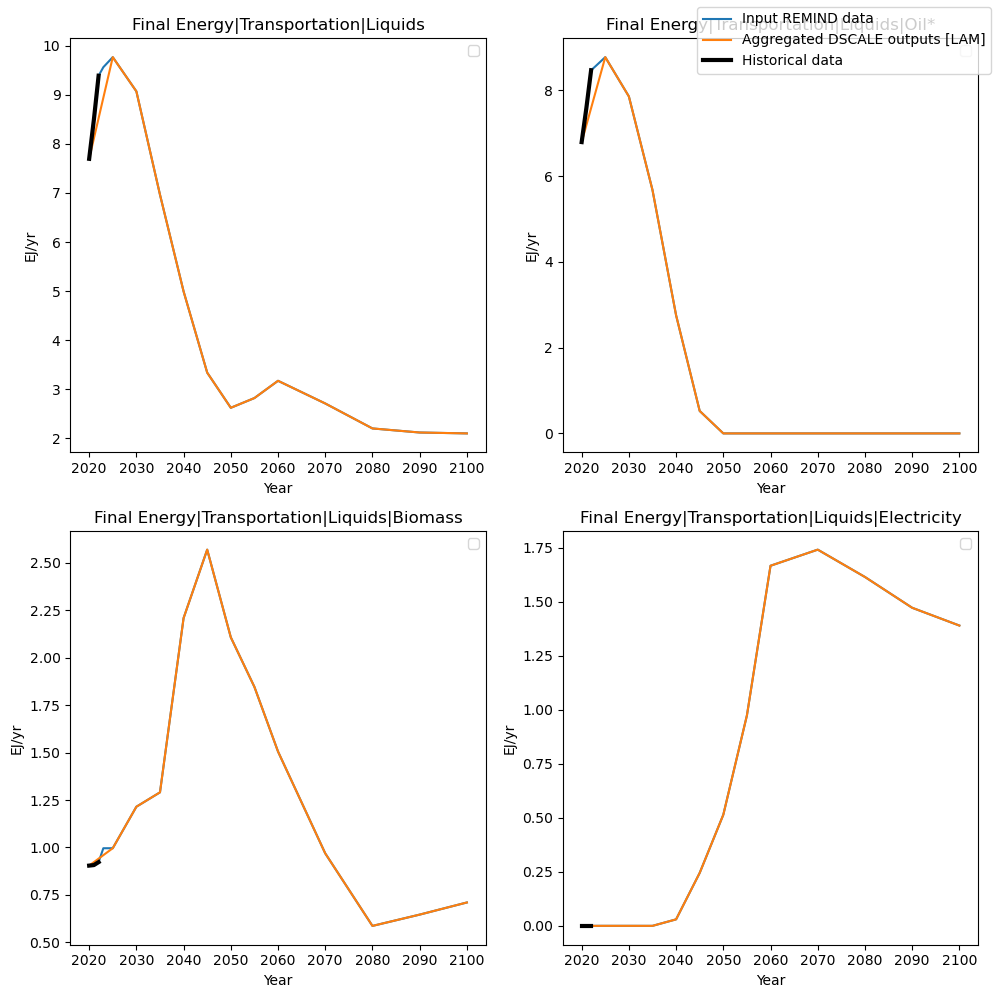

In [16]:
fuels = ['','|Oil*','|Biomass','|Electricity']
phase = 'Liquids'
sector = 'Transportation'


f, axes = plt.subplots(ncols=2,nrows=2,figsize=(10,10))

for count, ax in enumerate(axes.ravel()):

    input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2020,2101)).plot(ax=ax)
    dscale_results_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax)
    hist_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2023)).plot(ax=ax,color='k',lw=3)
    ax.set_title(f'Final Energy|{sector}|{phase}{fuels[count]}')

f.legend(['Input REMIND data','Aggregated DSCALE outputs [LAM]','Historical data'])
plt.tight_layout()

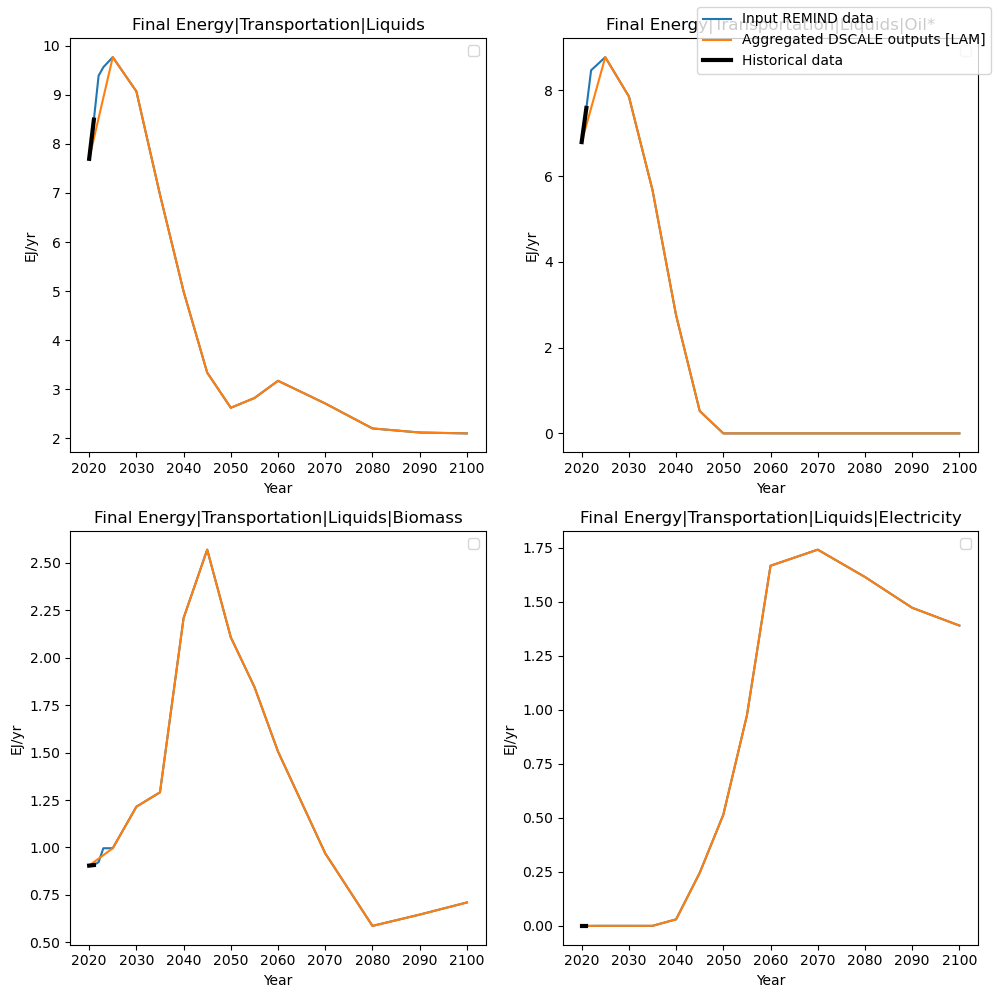

In [17]:
fuels = ['','|Oil*','|Biomass','|Electricity']
phase = 'Liquids'
sector = 'Transportation'


f, axes = plt.subplots(ncols=2,nrows=2,figsize=(10,10))

for count, ax in enumerate(axes.ravel()):

    input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2020,2101)).plot(ax=ax)
    dscale_results_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax)
    hist_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2022)).plot(ax=ax,color='k',lw=3)
    ax.set_title(f'Final Energy|{sector}|{phase}{fuels[count]}')

f.legend(['Input REMIND data','Aggregated DSCALE outputs [LAM]','Historical data'])
plt.tight_layout()

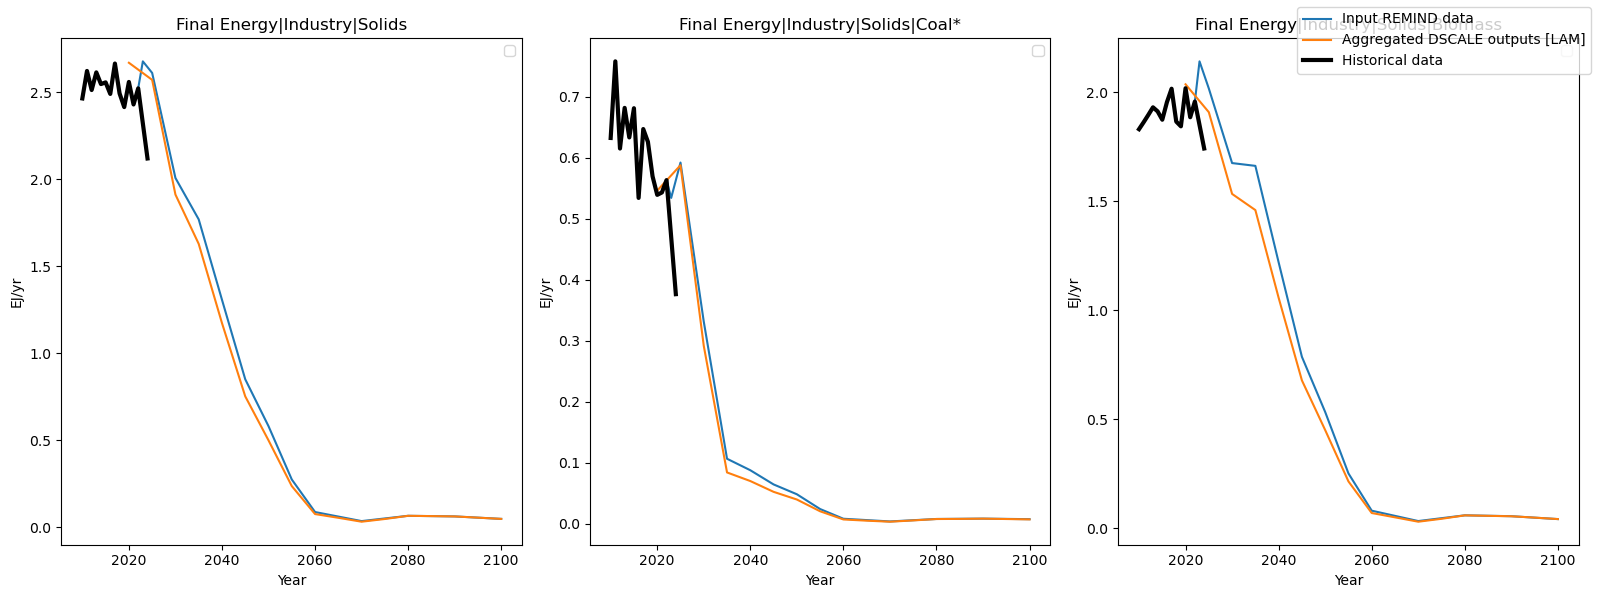

In [18]:
fuels = ['','|Coal*','|Biomass']
phase = 'Solids'
sector = 'Industry'


f, axes = plt.subplots(ncols=3,figsize=(16,6))

for count, ax in enumerate(axes.ravel()):

    input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2010,2101)).plot(ax=ax)
    # input_data_processed.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2020,2101)).plot(ax=ax)
    dscale_results_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax)
    hist_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2010,2101)).plot(ax=ax,color='k',lw=3)
    ax.set_title(f'Final Energy|{sector}|{phase}{fuels[count]}')

f.legend(['Input REMIND data','Aggregated DSCALE outputs [LAM]','Historical data'])
plt.tight_layout()

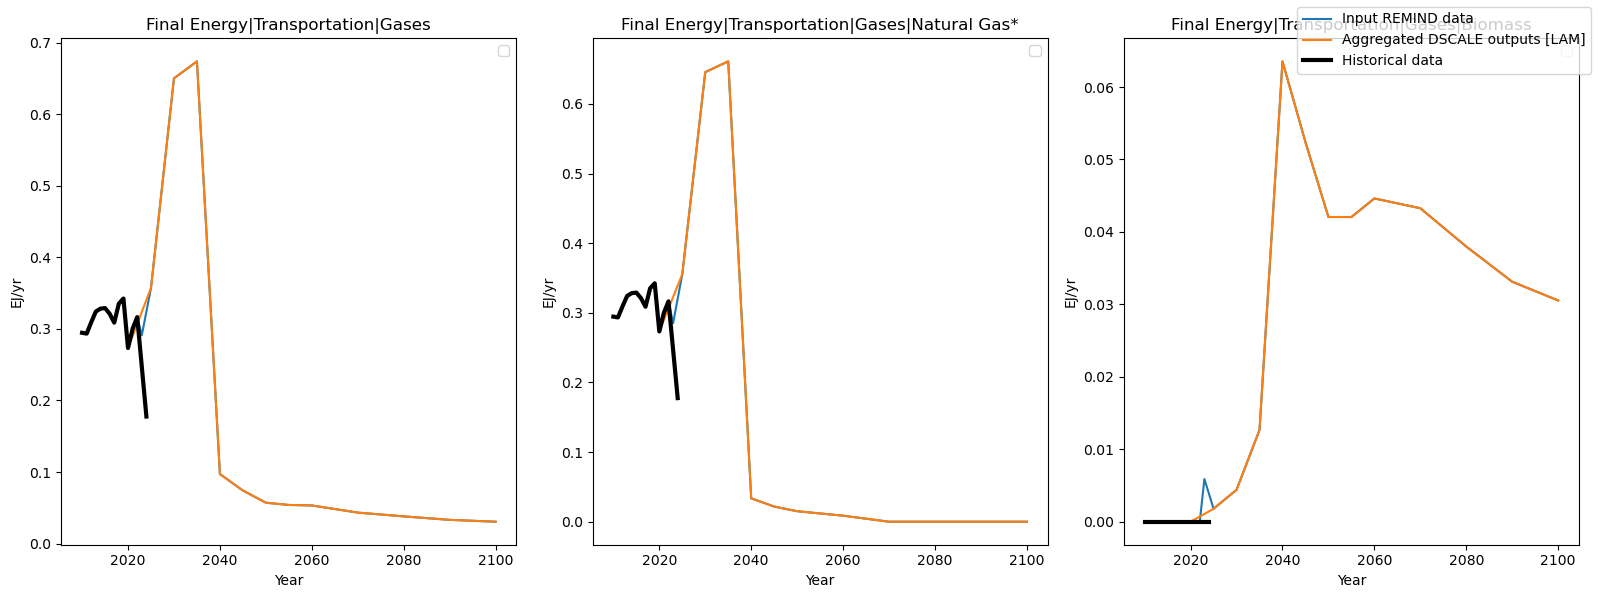

In [19]:
fuels = ['','|Natural Gas*','|Biomass']
phase = 'Gases'
sector = 'Transportation'


f, axes = plt.subplots(ncols=3,figsize=(16,6))

for count, ax in enumerate(axes.ravel()):

    input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2010,2101)).plot(ax=ax)
    # input_data_processed.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2020,2101)).plot(ax=ax)
    dscale_results_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax)
    hist_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2010,2101)).plot(ax=ax,color='k',lw=3)
    ax.set_title(f'Final Energy|{sector}|{phase}{fuels[count]}')

f.legend(['Input REMIND data','Aggregated DSCALE outputs [LAM]','Historical data'])
plt.tight_layout()

## Second – looking at inter-sector and cross-sector consistency
Do carriers add up to the total per sector? Do sectors add up to the total final energy?

In [20]:
def find_sector_aggregation_issues(sector, N=25, rtol=2.5e-2, atol=1e-3):
    """Find issues with sector aggregation
    
    Arguments:
    - sector: str: Choose sector for analysis
    - N=25: int: Number of problem sectors to highlight (the top N)
    - rtol: float: Relative tolerance for finding deviations, passed to numpy.isclose
    - atol: float: Absolute tolerance for finding deviations, passed to numpy.isclose
    
    
    """
    component_df = dscale_results.filter(year=range(2035,2051)).check_aggregate(
            f'Final Energy|{sector}',
            [
                f'Final Energy|{sector}|Liquids',
                f'Final Energy|{sector}|Solids',
                f'Final Energy|{sector}|Gases',
                f'Final Energy|{sector}|Heat',
                f'Final Energy|{sector}|Hydrogen',
                f'Final Energy|{sector}|Electricity',
            ], rtol=rtol, atol=atol
        )
    
    problem_results = (component_df/component_df.shift(axis=1) - 1).abs().sort_values('components').loc[isin(region=IKEA_ISOS)].tail(N).index

    return component_df.loc[problem_results]


    

In [21]:
find_sector_aggregation_issues('Transportation')

[INFO] 11:24:34 - pyam.core: `Final Energy|Transportation` - 508 of 772 rows are not aggregates of components


variable  \
model      scenario region variable                    unit  year             
REMIND 3.4 NPE-core MEX    Final Energy|Transportation EJ/yr 2035    2.1617   
                    MAR    Final Energy|Transportation EJ/yr 2050    0.1803   
                    SEN    Final Energy|Transportation EJ/yr 2040    0.1417   
                                                             2045    0.1501   
                    BGD    Final Energy|Transportation EJ/yr 2035    0.7502   
                    BRA    Final Energy|Transportation EJ/yr 2040    3.3436   
                    SEN    Final Energy|Transportation EJ/yr 2035    0.1867   
                    BGD    Final Energy|Transportation EJ/yr 2045    0.5970   
                                                             2050    0.6632   
                    IDN    Final Energy|Transportation EJ/yr 2040    2.7699   
                    BRA    Final Energy|Transportation EJ/yr 2050    3.1908   
                                                             2045    3.1081   
                    IDN    Final Energy|Transportation EJ/yr 2050    2.4903   
                    VNM    Final Energy|Transportation EJ/yr 2035    1.0055   
                    IDN    Final Energy|Transportation EJ/yr 2045    2.4612   
                    MEX    Final Energy|Transportation EJ/yr 2050    2.0673   
                    VNM    Final Energy|Transportation EJ/yr 2040    0.6786   
                    MEX    Final Energy|Transportation EJ/yr 2040    1.9526   
                                                             2045    1.9600   
                    VNM    Final Energy|Transportation EJ/yr 2045    0.7425   
                                                             2050    0.8848   
                    ZAF    Final Energy|Transportation EJ/yr 2035    0.4773   
                                                             2050    0.7946   
                                                             2045    0.6716   
                                                             2040    0.5917   

                                                                   components  
model      scenario region variable                    unit  year              
REMIND 3.4 NPE-core MEX    Final Energy|Transportation EJ/yr 2035    2.678617  
                    MAR    Final Energy|Transportation EJ/yr 2050    0.224340  
                    SEN    Final Energy|Transportation EJ/yr 2040    0.106240  
                                                             2045    0.112053  
                    BGD    Final Energy|Transportation EJ/yr 2035    0.555040  
                    BRA    Final Energy|Transportation EJ/yr 2040    4.239115  
                    SEN    Final Energy|Transportation EJ/yr 2035    0.135928  
                    BGD    Final Energy|Transportation EJ/yr 2045    0.433611  
                                                             2050    0.455952  
                    IDN    Final Energy|Transportation EJ/yr 2040    3.709653  
                    BRA    Final Energy|Transportation EJ/yr 2050    4.282522  
                                                             2045    4.242560  
                    IDN    Final Energy|Transportation EJ/yr 2050    3.479737  
                    VNM    Final Energy|Transportation EJ/yr 2035    0.574212  
                    IDN    Final Energy|Transportation EJ/yr 2045    3.568066  
                    MEX    Final Energy|Transportation EJ/yr 2050    3.009748  
                    VNM    Final Energy|Transportation EJ/yr 2040    0.363323  
                    MEX    Final Energy|Transportation EJ/yr 2040    2.895489  
                                                             2045    2.992713  
                    VNM    Final Energy|Transportation EJ/yr 2045    0.287981  
                                                             2050    0.298431  
                    ZAF    Final Energy|Transportation EJ/yr 2035    0.827926  
             

In [22]:
find_sector_aggregation_issues('Industry')

[INFO] 11:24:34 - pyam.core: `Final Energy|Industry` - 522 of 772 rows are not aggregates of components


variable  \
model      scenario region variable              unit  year             
REMIND 3.4 NPE-core GBR    Final Energy|Industry EJ/yr 2040    0.6635   
                    MAR    Final Energy|Industry EJ/yr 2035    0.3209   
                    IDN    Final Energy|Industry EJ/yr 2035    5.5699   
                    MEX    Final Energy|Industry EJ/yr 2045    2.2810   
                                                       2040    2.1753   
                    IDN    Final Energy|Industry EJ/yr 2045    8.1887   
                                                       2040    7.3481   
                    PAK    Final Energy|Industry EJ/yr 2040    3.5631   
                    SEN    Final Energy|Industry EJ/yr 2035    0.1291   
                    PAK    Final Energy|Industry EJ/yr 2050    5.0562   
                                                       2045    4.1564   
                    SEN    Final Energy|Industry EJ/yr 2050    0.2799   
                    ARE    Final Energy|Industry EJ/yr 2050    0.8051   
                    NGA    Final Energy|Industry EJ/yr 2035    2.0808   
                    SEN    Final Energy|Industry EJ/yr 2045    0.2207   
                    ARE    Final Energy|Industry EJ/yr 2045    0.8634   
                    SEN    Final Energy|Industry EJ/yr 2040    0.1779   
                    NGA    Final Energy|Industry EJ/yr 2050    5.2591   
                                                       2040    3.0624   
                    ARE    Final Energy|Industry EJ/yr 2035    1.1048   
                    NGA    Final Energy|Industry EJ/yr 2045    4.2454   
                    ARE    Final Energy|Industry EJ/yr 2040    1.0339   
                    MAR    Final Energy|Industry EJ/yr 2050    0.8271   
                                                       2040    0.4694   
                                                       2045    0.6360   

                                                             components  
model      scenario region variable              unit  year              
REMIND 3.4 NPE-core GBR    Final Energy|Industry EJ/yr 2040    0.743516  
                    MAR    Final Energy|Industry EJ/yr 2035    0.360983  
                    IDN    Final Energy|Industry EJ/yr 2035    6.279826  
                    MEX    Final Energy|Industry EJ/yr 2045    2.574917  
                                                       2040    2.498391  
                    IDN    Final Energy|Industry EJ/yr 2045    9.437698  
                                                       2040    8.592750  
                    PAK    Final Energy|Industry EJ/yr 2040    4.170032  
                    SEN    Final Energy|Industry EJ/yr 2035    0.153628  
                    PAK    Final Energy|Industry EJ/yr 2050    6.029179  
                                                       2045    5.031962  
                    SEN    Final Energy|Industry EJ/yr 2050    0.341195  
                    ARE    Final Energy|Industry EJ/yr 2050    0.616161  
                    NGA    Final Energy|Industry EJ/yr 2035    1.567465  
                    SEN    Final Energy|Industry EJ/yr 2045    0.279646  
                    ARE    Final Energy|Industry EJ/yr 2045    0.625164  
                    SEN    Final Energy|Industry EJ/yr 2040    0.229120  
                    NGA    Final Energy|Industry EJ/yr 2050    3.743078  
                                                       2040    2.178888  
                    ARE    Final Energy|Industry EJ/yr 2035    0.776347  
                    NGA    Final Energy|Industry EJ/yr 2045    2.928461  
                    ARE    Final Energy|Industry EJ/yr 2040    0.703244  
                    MAR    Final Energy|Industry EJ/yr 2050    1.208238  
                                                       2040    0.702224  
                                                       2045    0.961774

In [23]:
find_sector_aggregation_issues('Residential and Commercial')

[INFO] 11:24:34 - pyam.core: `Final Energy|Residential and Commercial` - 459 of 772 rows are not aggregates of components


variable  \
model      scenario region variable                                unit  year             
REMIND 3.4 NPE-core POL    Final Energy|Residential and Commercial EJ/yr 2050    0.6970   
                    DEU    Final Energy|Residential and Commercial EJ/yr 2045    1.6619   
                                                                         2040    1.8717   
                    BGD    Final Energy|Residential and Commercial EJ/yr 2040    1.3542   
                    POL    Final Energy|Residential and Commercial EJ/yr 2035    0.9063   
                    MAR    Final Energy|Residential and Commercial EJ/yr 2040    0.3439   
                    POL    Final Energy|Residential and Commercial EJ/yr 2045    0.7349   
                    BGD    Final Energy|Residential and Commercial EJ/yr 2035    0.9406   
                    ZAF    Final Energy|Residential and Commercial EJ/yr 2045    0.4206   
                    NAM    Final Energy|Residential and Commercial EJ/yr 2035    0.0277   
                    POL    Final Energy|Residential and Commercial EJ/yr 2040    0.8100   
                    ZAF    Final Energy|Residential and Commercial EJ/yr 2040    0.4556   
                                                                         2035    0.5011   
                    MAR    Final Energy|Residential and Commercial EJ/yr 2035    0.3025   
                    NAM    Final Energy|Residential and Commercial EJ/yr 2040    0.0262   
                                                                         2050    0.0277   
                                                                         2045    0.0243   
                    VNM    Final Energy|Residential and Commercial EJ/yr 2050    1.3406   
                                                                         2045    1.1651   
                    SEN    Final Energy|Residential and Commercial EJ/yr 2050    0.1308   
                    VNM    Final Energy|Residential and Commercial EJ/yr 2040    1.0622   
                                                                         2035    0.7718   
                    SEN    Final Energy|Residential and Commercial EJ/yr 2045    0.1007   
                                                                         2035    0.0796   
                                                                         2040    0.0877   

                                                                               components  
model      scenario region variable                                unit  year              
REMIND 3.4 NPE-core POL    Final Energy|Residential and Commercial EJ/yr 2050    0.819072  
                    DEU    Final Energy|Residential and Commercial EJ/yr 2045    1.368676  
                                                                         2040    1.525214  
                    BGD    Final Energy|Residential and Commercial EJ/yr 2040    1.622328  
                    POL    Final Energy|Residential and Commercial EJ/yr 2035    1.092744  
                    MAR    Final Energy|Residential and Commercial EJ/yr 2040    0.415015  
                    POL    Final Energy|Residential and Commercial EJ/yr 2045    0.887011  
                    BGD    Final Energy|Residential and Commercial EJ/yr 2035    1.135589  
                    ZAF    Final Energy|Residential and Commercial EJ/yr 2045    0.508181  
                    NAM    Final Energy|Residential and Commercial EJ/yr 2035    0.021649  
                    POL    Final Energy|Residential and Commercial EJ/yr 2040    1.001094  
                    ZAF    Final Energy|Residential and Commercial EJ/yr 2040    0.565423  
                                                                         2035    0.627582  
                    MAR    Final Energy|Residential and Commercial EJ/yr 2035    0.384795  
                    NAM    Final Energy|Residential and Commercial EJ/yr 2040    0.018167  
                                                         

In [24]:
def find_carrier_aggregation_issues(carrier, N=25, rtol=2.5e-2, atol=1e-3):
    """Find issues with carrier aggregation
    
    Arguments:
    - carrier: str: Choose carrier for analysis
    - N=25: int: Number of problem carrier to highlight (the top N)
    - rtol: float: Relative tolerance for finding deviations, passed to numpy.isclose
    - atol: float: Absolute tolerance for finding deviations, passed to numpy.isclose
    
    
    """
    component_df = dscale_results.filter(year=range(2035,2051)).check_aggregate(
            f'Final Energy|{carrier}',
            [
                f'Final Energy|Residential and Commercial|{carrier}',
                f'Final Energy|Transportation|{carrier}',
                f'Final Energy|Industry|{carrier}',
            ], rtol=rtol, atol=atol
        )
    
    problem_results = (component_df/component_df.shift(axis=1) - 1).abs().sort_values('components').loc[isin(region=IKEA_ISOS)].tail(N).index

    return component_df.loc[problem_results]


    

In [25]:
find_carrier_aggregation_issues('Electricity')

[INFO] 11:24:34 - pyam.core: `Final Energy|Electricity` - 492 of 772 rows are not aggregates of components


variable  \
model      scenario region variable                 unit  year             
REMIND 3.4 NPE-core ARE    Final Energy|Electricity EJ/yr 2035    1.1118   
                    VNM    Final Energy|Electricity EJ/yr 2045    5.0082   
                    ARE    Final Energy|Electricity EJ/yr 2040    1.2663   
                                                          2045    1.3457   
                    DZA    Final Energy|Electricity EJ/yr 2035    0.3648   
                    MAR    Final Energy|Electricity EJ/yr 2045    1.0915   
                    MEX    Final Energy|Electricity EJ/yr 2040    3.8874   
                    IDN    Final Energy|Electricity EJ/yr 2040    9.4057   
                    BGD    Final Energy|Electricity EJ/yr 2035    1.9697   
                    DZA    Final Energy|Electricity EJ/yr 2040    0.9486   
                    AUS    Final Energy|Electricity EJ/yr 2045    1.4234   
                    VNM    Final Energy|Electricity EJ/yr 2050    5.4286   
                    SAU    Final Energy|Electricity EJ/yr 2050    4.7154   
                    BRA    Final Energy|Electricity EJ/yr 2035    4.2236   
                    ARE    Final Energy|Electricity EJ/yr 2050    1.4753   
                    AUS    Final Energy|Electricity EJ/yr 2050    1.4992   
                    MAR    Final Energy|Electricity EJ/yr 2050    1.4294   
                    VNM    Final Energy|Electricity EJ/yr 2035    3.2912   
                    MEX    Final Energy|Electricity EJ/yr 2035    2.8396   
                    DZA    Final Energy|Electricity EJ/yr 2045    1.7400   
                                                          2050    2.1392   
                    ZAF    Final Energy|Electricity EJ/yr 2050    2.2057   
                                                          2035    1.3593   
                                                          2045    2.0011   
                                                          2040    1.8103   

                                                                components  
model      scenario region variable                 unit  year              
REMIND 3.4 NPE-core ARE    Final Energy|Electricity EJ/yr 2035      0.9520  
                    VNM    Final Energy|Electricity EJ/yr 2045      4.2684  
                    ARE    Final Energy|Electricity EJ/yr 2040      1.0778  
                                                          2045      1.1393  
                    DZA    Final Energy|Electricity EJ/yr 2035      0.3073  
                    MAR    Final Energy|Electricity EJ/yr 2045      0.9189  
                    MEX    Final Energy|Electricity EJ/yr 2040      4.5077  
                    IDN    Final Energy|Electricity EJ/yr 2040     10.9238  
                    BGD    Final Energy|Electricity EJ/yr 2035      1.6486  
                    DZA    Final Energy|Electricity EJ/yr 2040      0.7937  
                    AUS    Final Energy|Electricity EJ/yr 2045      1.1809  
                    VNM    Final Energy|Electricity EJ/yr 2050      4.4870  
                    SAU    Final Energy|Electricity EJ/yr 2050      3.8975  
                    BRA    Final Energy|Electricity EJ/yr 2035      4.9792  
                    ARE    Final Energy|Electricity EJ/yr 2050      1.2026  
                    AUS    Final Energy|Electricity EJ/yr 2050      1.2174  
                    MAR    Final Energy|Electricity EJ/yr 2050      1.1604  
                    VNM    Final Energy|Electricity EJ/yr 2035      2.6510  
                    MEX    Final Energy|Electricity EJ/yr 2035      3.3946  
                    DZA    Final Energy|Electricity EJ/yr 2045      1.3777  
                                                          2050      1.6409  
                    ZAF    Final Energy|Electricity EJ/yr 2050      2.7495  
                                                          2035      1.7268  
                                                          2045      2.6443  
         

In [26]:
find_carrier_aggregation_issues('Liquids')

[INFO] 11:24:34 - pyam.core: `Final Energy|Liquids` - 510 of 772 rows are not aggregates of components


variable  \
model      scenario region variable             unit  year             
REMIND 3.4 NPE-core KEN    Final Energy|Liquids EJ/yr 2040    0.2764   
                    VNM    Final Energy|Liquids EJ/yr 2040    0.9333   
                    KEN    Final Energy|Liquids EJ/yr 2035    0.3443   
                    MEX    Final Energy|Liquids EJ/yr 2040    1.1666   
                    DZA    Final Energy|Liquids EJ/yr 2040    1.0702   
                    IDN    Final Energy|Liquids EJ/yr 2040    3.2868   
                    SAU    Final Energy|Liquids EJ/yr 2040    0.5721   
                    ZAF    Final Energy|Liquids EJ/yr 2050    0.1558   
                    MEX    Final Energy|Liquids EJ/yr 2035    2.0542   
                    BRA    Final Energy|Liquids EJ/yr 2035    4.1533   
                    VNM    Final Energy|Liquids EJ/yr 2035    1.2429   
                    NGA    Final Energy|Liquids EJ/yr 2045    1.3529   
                                                      2035    1.7799   
                    DZA    Final Energy|Liquids EJ/yr 2045    0.9355   
                    IDN    Final Energy|Liquids EJ/yr 2045    2.4548   
                                                      2050    2.4137   
                    DZA    Final Energy|Liquids EJ/yr 2050    1.1045   
                    NGA    Final Energy|Liquids EJ/yr 2040    1.7171   
                                                      2050    1.1875   
                    SAU    Final Energy|Liquids EJ/yr 2045    0.3558   
                                                      2050    0.3890   
                    BGD    Final Energy|Liquids EJ/yr 2035    1.2520   
                                                      2040    1.3455   
                                                      2050    1.2338   
                                                      2045    1.1645   

                                                            components  
model      scenario region variable             unit  year              
REMIND 3.4 NPE-core KEN    Final Energy|Liquids EJ/yr 2040    0.229006  
                    VNM    Final Energy|Liquids EJ/yr 2040    0.773115  
                    KEN    Final Energy|Liquids EJ/yr 2035    0.284728  
                    MEX    Final Energy|Liquids EJ/yr 2040    0.961984  
                    DZA    Final Energy|Liquids EJ/yr 2040    0.880267  
                    IDN    Final Energy|Liquids EJ/yr 2040    2.692607  
                    SAU    Final Energy|Liquids EJ/yr 2040    0.677297  
                    ZAF    Final Energy|Liquids EJ/yr 2050    0.184864  
                    MEX    Final Energy|Liquids EJ/yr 2035    1.666548  
                    BRA    Final Energy|Liquids EJ/yr 2035    3.362059  
                    VNM    Final Energy|Liquids EJ/yr 2035    0.991654  
                    NGA    Final Energy|Liquids EJ/yr 2045    1.072238  
                                                      2035    1.404684  
                    DZA    Final Energy|Liquids EJ/yr 2045    0.730426  
                    IDN    Final Energy|Liquids EJ/yr 2045    1.912985  
                                                      2050    1.876468  
                    DZA    Final Energy|Liquids EJ/yr 2050    0.856368  
                    NGA    Final Energy|Liquids EJ/yr 2040    1.322320  
                                                      2050    0.910692  
                    SAU    Final Energy|Liquids EJ/yr 2045    0.447335  
                                                      2050    0.492575  
                    BGD    Final Energy|Liquids EJ/yr 2035    0.820661  
                                                      2040    0.846996  
                                                      2050    0.751189  
                                                      2045    0.704949

Look at whether Sum(sectors) = Final Energy

In [27]:
missing_final_energy = (
    dscale_results_agg
    .filter(variable=['Final Energy','Final Energy|Transportation','Final Energy|Industry','Final Energy|Residential and Commercial'])
    .check_aggregate(
        'Final Energy',
        ['Final Energy|Transportation','Final Energy|Industry','Final Energy|Residential and Commercial']
    ).diff(axis=1)
)

[INFO] 11:24:34 - pyam.core: `Final Energy` - 247 of 247 rows are not aggregates of components


In [28]:
inferred_other_sector = (missing_final_energy.components*-1).unstack('year').pix.assign(variable='Final Energy|Other Sector')

In [29]:
inferred_other_sector

year                                                           2010     2015  \
model      scenario region variable                  unit                      
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr   0.7270   0.8264   
                    CHA    Final Energy|Other Sector EJ/yr   3.4585   4.6691   
                    EUR    Final Energy|Other Sector EJ/yr   2.0620   1.9402   
                    IND    Final Energy|Other Sector EJ/yr   1.2956   1.7087   
                    JPN    Final Energy|Other Sector EJ/yr   0.4265   0.4036   
                    LAM    Final Energy|Other Sector EJ/yr   1.5332   1.6400   
                    MEA    Final Energy|Other Sector EJ/yr   0.9758   0.9464   
                    NEU    Final Energy|Other Sector EJ/yr   0.4828   0.3692   
                    OAS    Final Energy|Other Sector EJ/yr   1.0266   1.1749   
                    REF    Final Energy|Other Sector EJ/yr   1.0742   1.1347   
                    SSA    Final Energy|Other Sector EJ/yr   0.2531   0.3191   
                    USA    Final Energy|Other Sector EJ/yr   2.1425   2.1489   
                    World  Final Energy|Other Sector EJ/yr  15.4578  17.2812   

year                                                           2020     2025  \
model      scenario region variable                  unit                      
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr   0.7883   0.7941   
                    CHA    Final Energy|Other Sector EJ/yr   5.5017   6.4187   
                    EUR    Final Energy|Other Sector EJ/yr   2.2665   1.6847   
                    IND    Final Energy|Other Sector EJ/yr   1.8015   2.4830   
                    JPN    Final Energy|Other Sector EJ/yr   0.4392   0.3184   
                    LAM    Final Energy|Other Sector EJ/yr   1.5371   1.8368   
                    MEA    Final Energy|Other Sector EJ/yr   1.1290   1.3836   
                    NEU    Final Energy|Other Sector EJ/yr   0.4416   0.4079   
                    OAS    Final Energy|Other Sector EJ/yr   1.1398   1.2536   
                    REF    Final Energy|Other Sector EJ/yr   1.0811   0.9898   
                    SSA    Final Energy|Other Sector EJ/yr   0.3342   0.3300   
                    USA    Final Energy|Other Sector EJ/yr   2.1953   2.2023   
                    World  Final Energy|Other Sector EJ/yr  18.6553  20.1029   

year                                                           2030     2035  \
model      scenario region variable                  unit                      
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr   0.6334   0.5986   
                    CHA    Final Energy|Other Sector EJ/yr   5.2878   4.4038   
                    EUR    Final Energy|Other Sector EJ/yr   1.4211   1.1878   
                    IND    Final Energy|Other Sector EJ/yr   2.6252   2.6452   
                    JPN    Final Energy|Other Sector EJ/yr   0.2386   0.1800   
                    LAM    Final Energy|Other Sector EJ/yr   1.7047   1.9042   
                    MEA    Final Energy|Other Sector EJ/yr   1.5224   1.7729   
                    NEU    Final Energy|Other Sector EJ/yr   0.3353   0.2906   
                    OAS    Final Energy|Other Sector EJ/yr   2.3891   3.6348   
                    REF    Final Energy|Other Sector EJ/yr   0.7853   0.7704   
                    SSA    Final Energy|Other Sector EJ/yr   0.3299   0.4680   
                    USA    Final Energy|Other Sector EJ/yr   1.7936   1.7789   
                    World  Final Energy|Other Sector EJ/yr  19.0664  19.6352   

year                                                           2040     2045  \
model      scenario region variable                  unit                      
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr   0.8586   1.2109   
                    CHA    Final Energy|Other Sector EJ/yr   3.7418   3.7624   
                    EUR    Final Energy|Other Sector EJ/yr   1.1711   1.4322 

In [30]:
(
    inferred_other_sector / 
    input_data.filter(variable='Final Energy|Other Sector').timeseries()
).interpolate(axis=1).loc[:,2070:]

2070  \
model      scenario region variable                  unit               
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr   1.104375   
                    CHA    Final Energy|Other Sector EJ/yr   1.235952   
                    EUR    Final Energy|Other Sector EJ/yr   1.423600   
                    IND    Final Energy|Other Sector EJ/yr   1.158161   
                    JPN    Final Energy|Other Sector EJ/yr   1.075387   
                    LAM    Final Energy|Other Sector EJ/yr   1.141876   
                    MEA    Final Energy|Other Sector EJ/yr   1.258147   
                    NEU    Final Energy|Other Sector EJ/yr  22.043967   
                    OAS    Final Energy|Other Sector EJ/yr   1.333333   
                    REF    Final Energy|Other Sector EJ/yr   1.154124   
                    SSA    Final Energy|Other Sector EJ/yr   1.474131   
                    USA    Final Energy|Other Sector EJ/yr   1.054888   
                    World  Final Energy|Other Sector EJ/yr   1.230595   

                                                                 2075  \
model      scenario region variable                  unit               
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr   1.052196   
                    CHA    Final Energy|Other Sector EJ/yr   1.117967   
                    EUR    Final Energy|Other Sector EJ/yr   1.210845   
                    IND    Final Energy|Other Sector EJ/yr   1.079075   
                    JPN    Final Energy|Other Sector EJ/yr   1.037586   
                    LAM    Final Energy|Other Sector EJ/yr   1.070893   
                    MEA    Final Energy|Other Sector EJ/yr   1.129073   
                    NEU    Final Energy|Other Sector EJ/yr  13.083839   
                    OAS    Final Energy|Other Sector EJ/yr   1.166675   
                    REF    Final Energy|Other Sector EJ/yr   1.077090   
                    SSA    Final Energy|Other Sector EJ/yr   1.237103   
                    USA    Final Energy|Other Sector EJ/yr   1.027452   
                    World  Final Energy|Other Sector EJ/yr   1.115293   

                                                                2080  \
model      scenario region variable                  unit              
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr  1.000016   
                    CHA    Final Energy|Other Sector EJ/yr  0.999981   
                    EUR    Final Energy|Other Sector EJ/yr  0.998091   
                    IND    Final Energy|Other Sector EJ/yr  0.999990   
                    JPN    Final Energy|Other Sector EJ/yr  0.999786   
                    LAM    Final Energy|Other Sector EJ/yr  0.999911   
                    MEA    Final Energy|Other Sector EJ/yr  0.999998   
                    NEU    Final Energy|Other Sector EJ/yr  4.123711   
                    OAS    Final Energy|Other Sector EJ/yr  1.000016   
                    REF    Final Energy|Other Sector EJ/yr  1.000056   
                    SSA    Final Energy|Other Sector EJ/yr  1.000075   
                    USA    Final Energy|Other Sector EJ/yr  1.000016   
                    World  Final Energy|Other Sector EJ/yr  0.999992   

                                                                2085  \
model      scenario region variable                  unit              
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr  1.000029   
                    CHA    Final Energy|Other Sector EJ/yr  0.999969   
                    EUR    Final Energy|Other Sector EJ/yr  0.998560   
                    IND    Final Energy|Other Sector EJ/yr  0.999989   
                    JPN    Final Energy|Other Sector EJ/yr  0.999687   
                    LAM    Final Energy|Other Sector EJ/yr  0.999920   
                    MEA    Final Energy|Other Sector EJ/yr  0.999996   
                    NEU    Final Energy|Other Sector EJ/yr  1.079537   
                    OAS    Final Energy|Other Sector EJ/yr  0.999998   


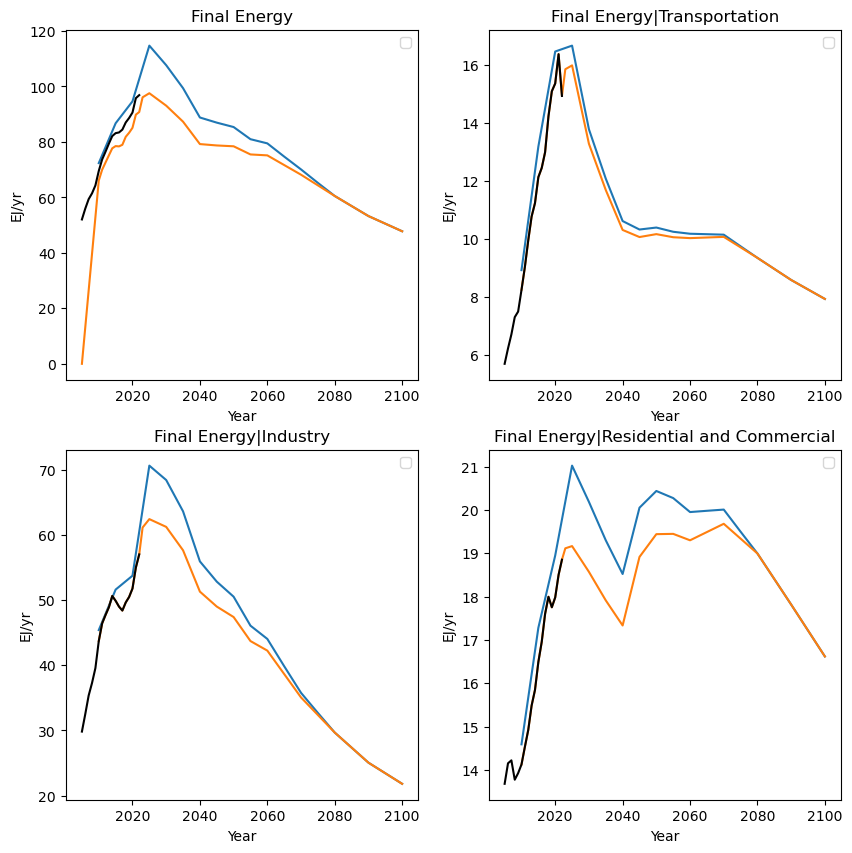

In [31]:
f, ax = plt.subplots(nrows=2,ncols=2,figsize=(10,10))
plot_region = 'CHA'

sectors = ['Final Energy','Final Energy|Transportation','Final Energy|Industry','Final Energy|Residential and Commercial']

for count, ax in enumerate(ax.ravel()):
    plt.sca(ax)
    dscale_results_agg.filter(variable=sectors[count],region=plot_region).plot(ax=plt.gca())
    input_data.filter(variable=sectors[count],region=plot_region).plot(ax=plt.gca())
    hist_agg.filter(variable=sectors[count],region=plot_region,year=range(2005,2024)).plot(ax=plt.gca(),color='k')
    ax.set_title(f'{sectors[count]}')

Look at whether Secondary Energy|Electricity is ever bigger than Final Energy

In [35]:
tnd_losses = dscale_results.divide(
    'Final Energy|Electricity',
    'Secondary Energy|Electricity',
    'Transmission Losses'
).timeseries()

In [36]:
problem_isos = tnd_losses.loc[(tnd_losses.loc[:,2030:]>1).any(axis=1)].loc[isin(region=IKEA_ISOS)].pix.project('region').index

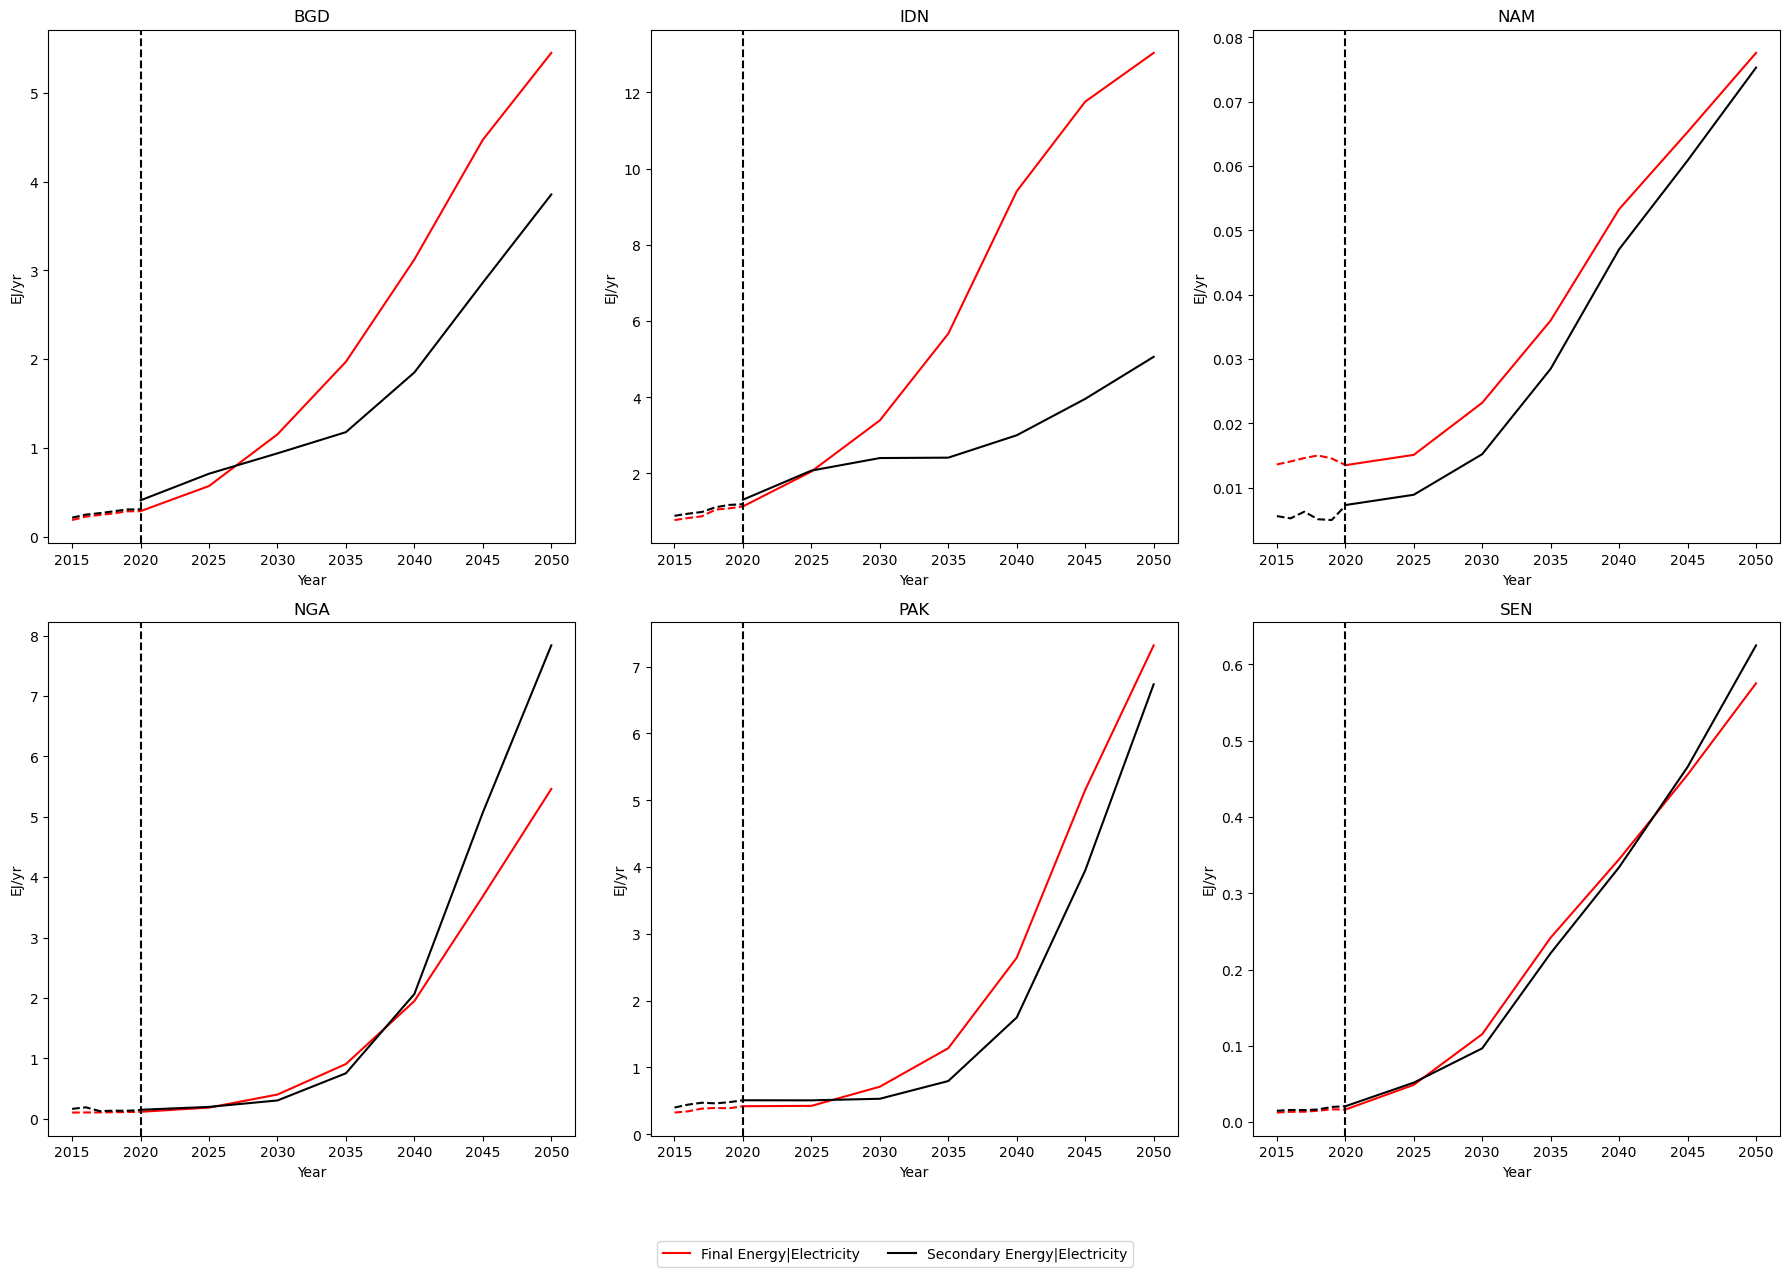

In [38]:
year_proj = [
    2020,
 2025,
 2030,
 2035,
 2040,
 2045,
 2050,
 ]

f, axes = plt.subplots(nrows=int(np.ceil(len(problem_isos)/3)), ncols=3, figsize=(18, 12))

color_map = {
    'Secondary Energy|Electricity':'k',
    'Final Energy|Electricity':'r'
}

pyam.run_control().update({"color": {"variable": color_map}})

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        scenario='NPE-core',
        region=problem_isos[count],
        variable=['Final Energy|Electricity','Secondary Energy|Electricity'],
        year = year_proj
    ).plot(ax=ax,color='variable')

    hist_data_iea.filter(
        region=problem_isos[count],
        variable=['Final Energy|Electricity','Secondary Energy|Electricity'],
        year=[2015, 2016, 2017, 2018, 2019, 2020]
    ).plot(ax=ax,linestyle='--',color='variable')

    ax.axvline(x=2020, color='k', ls='--')
    ax.set_title(problem_isos[count])
    ax.legend().remove()

f.legend(['Final Energy|Electricity','Secondary Energy|Electricity'],ncol=2,loc='center',bbox_to_anchor=[0.5,-0.05])

# f.suptitle('Transport sector mix',fontsize=14,fontweight='bold')
# f.legend(transport_legend_key,[l.get_label() for l in transport_legend_key],ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

plt.tight_layout()

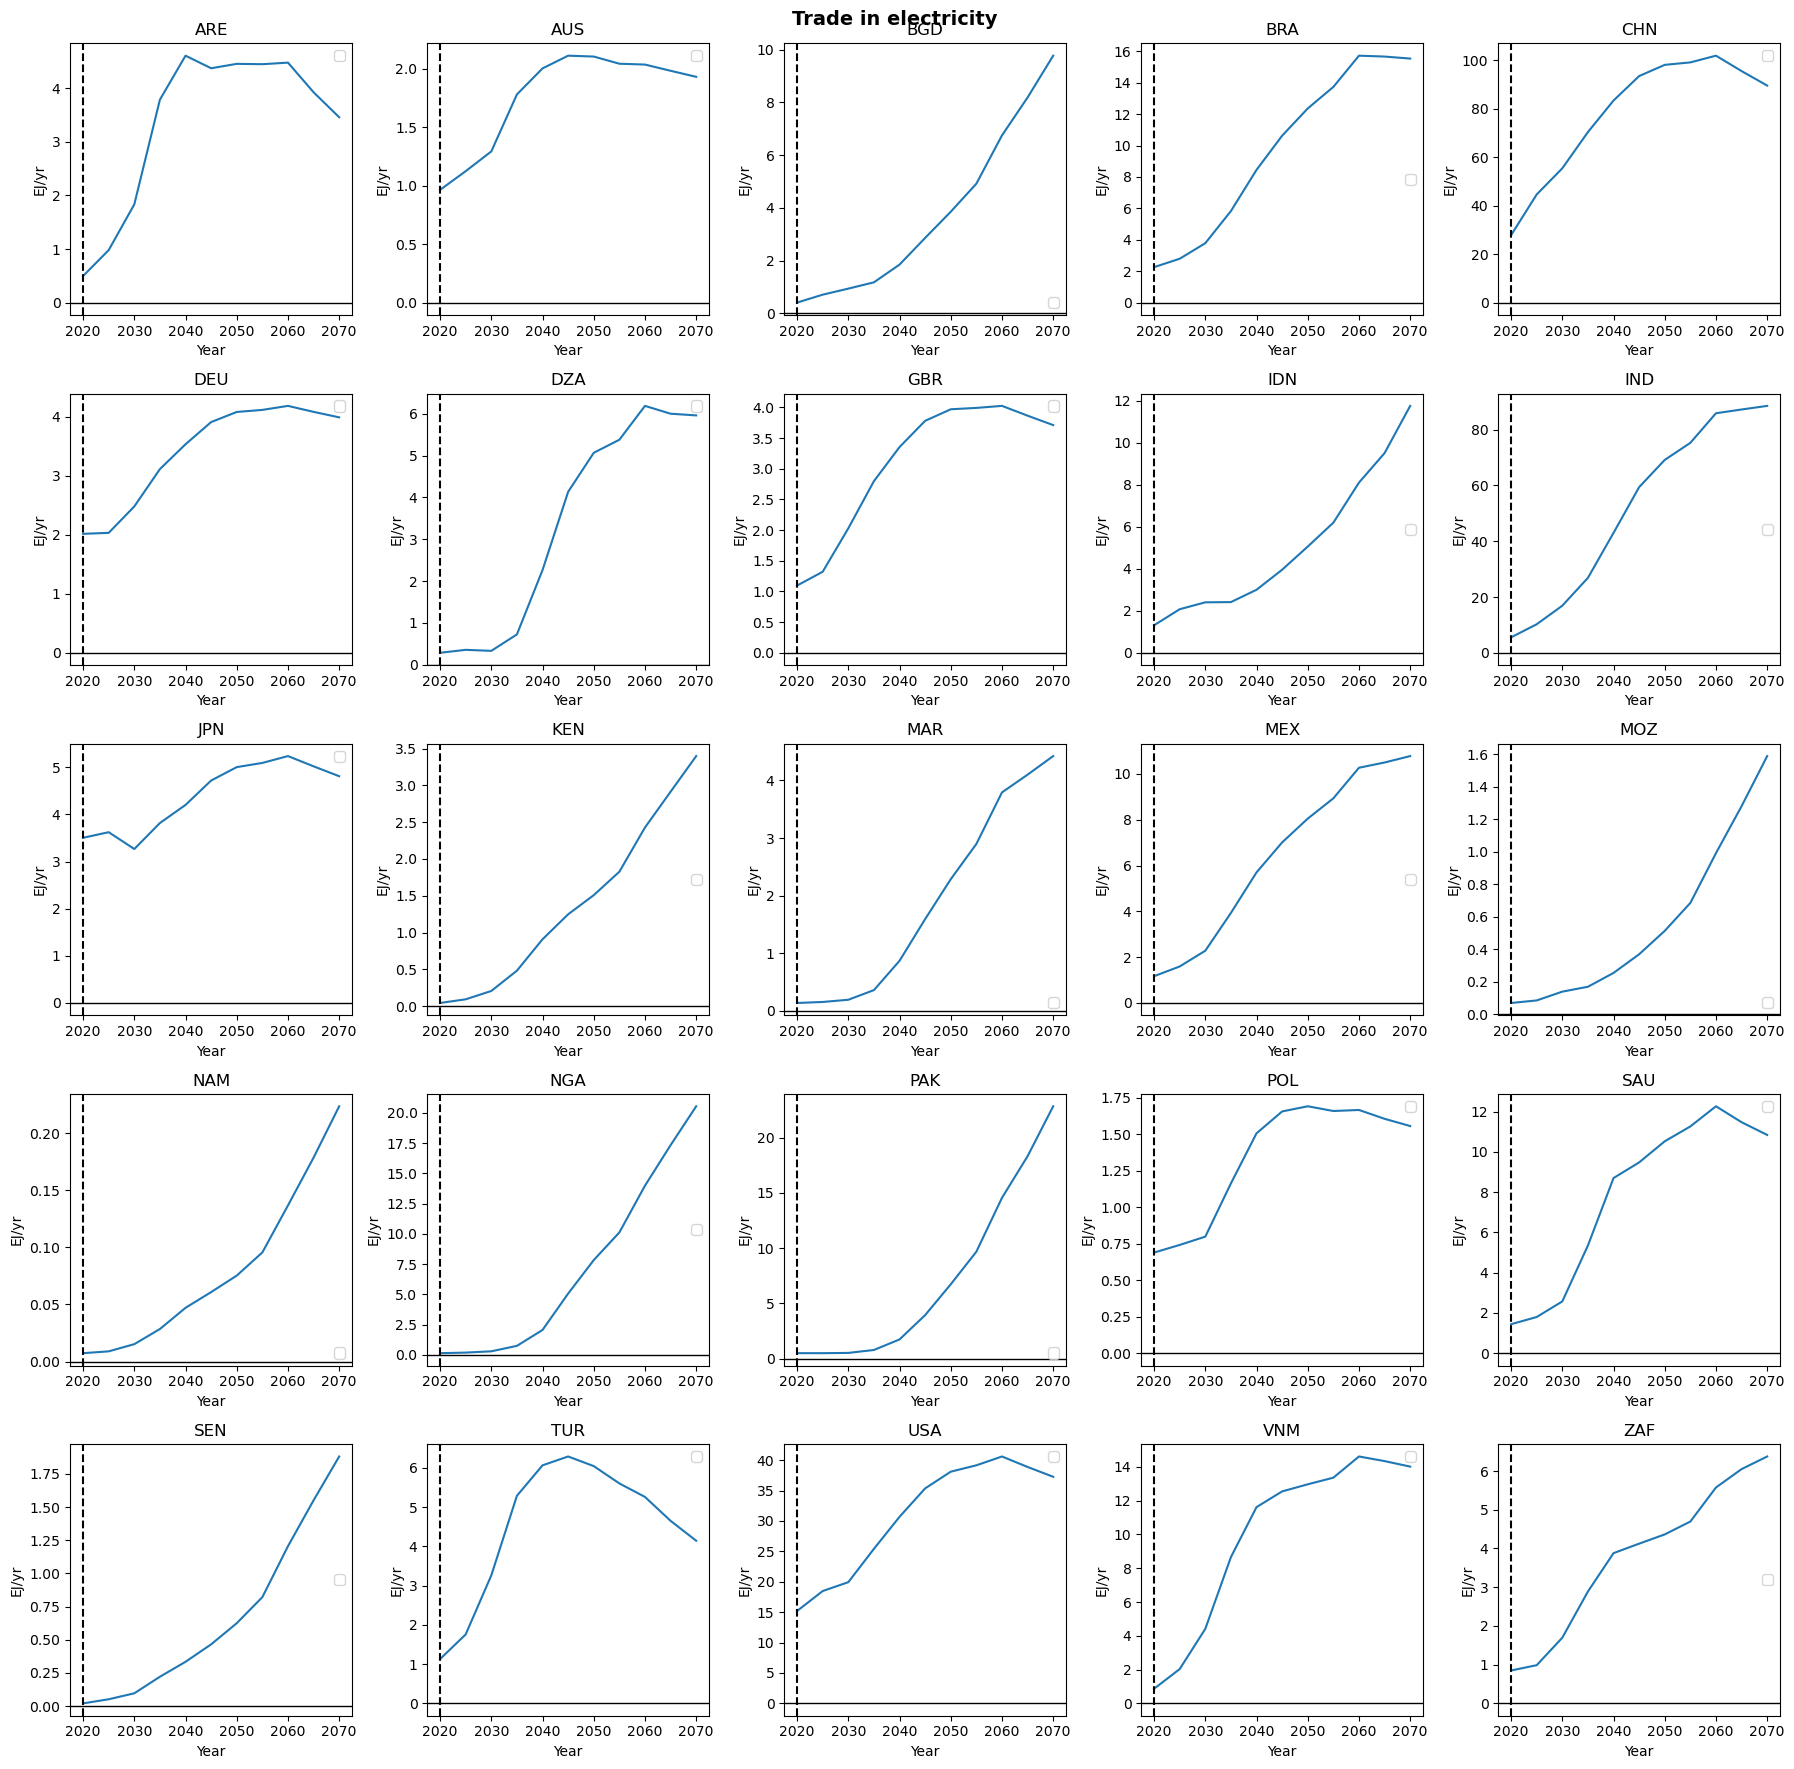

In [39]:
year_proj = range(2020,2071,5)

f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable='Secondary Energy|Electricity',
        year = year_proj
    ).plot(ax=ax)

    ax.axvline(x=2020, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.axhline(y=0,color='k',lw=1)

# ax.legend(ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

f.suptitle('Trade in electricity',fontsize=14,fontweight='bold')

plt.tight_layout()

In [40]:
dscale_results.divide(
    'Secondary Energy|Electricity|Trade',
    'Secondary Energy|Electricity',
    'Secondary Energy|Electricity|Trade|% of total',
    append=True
)

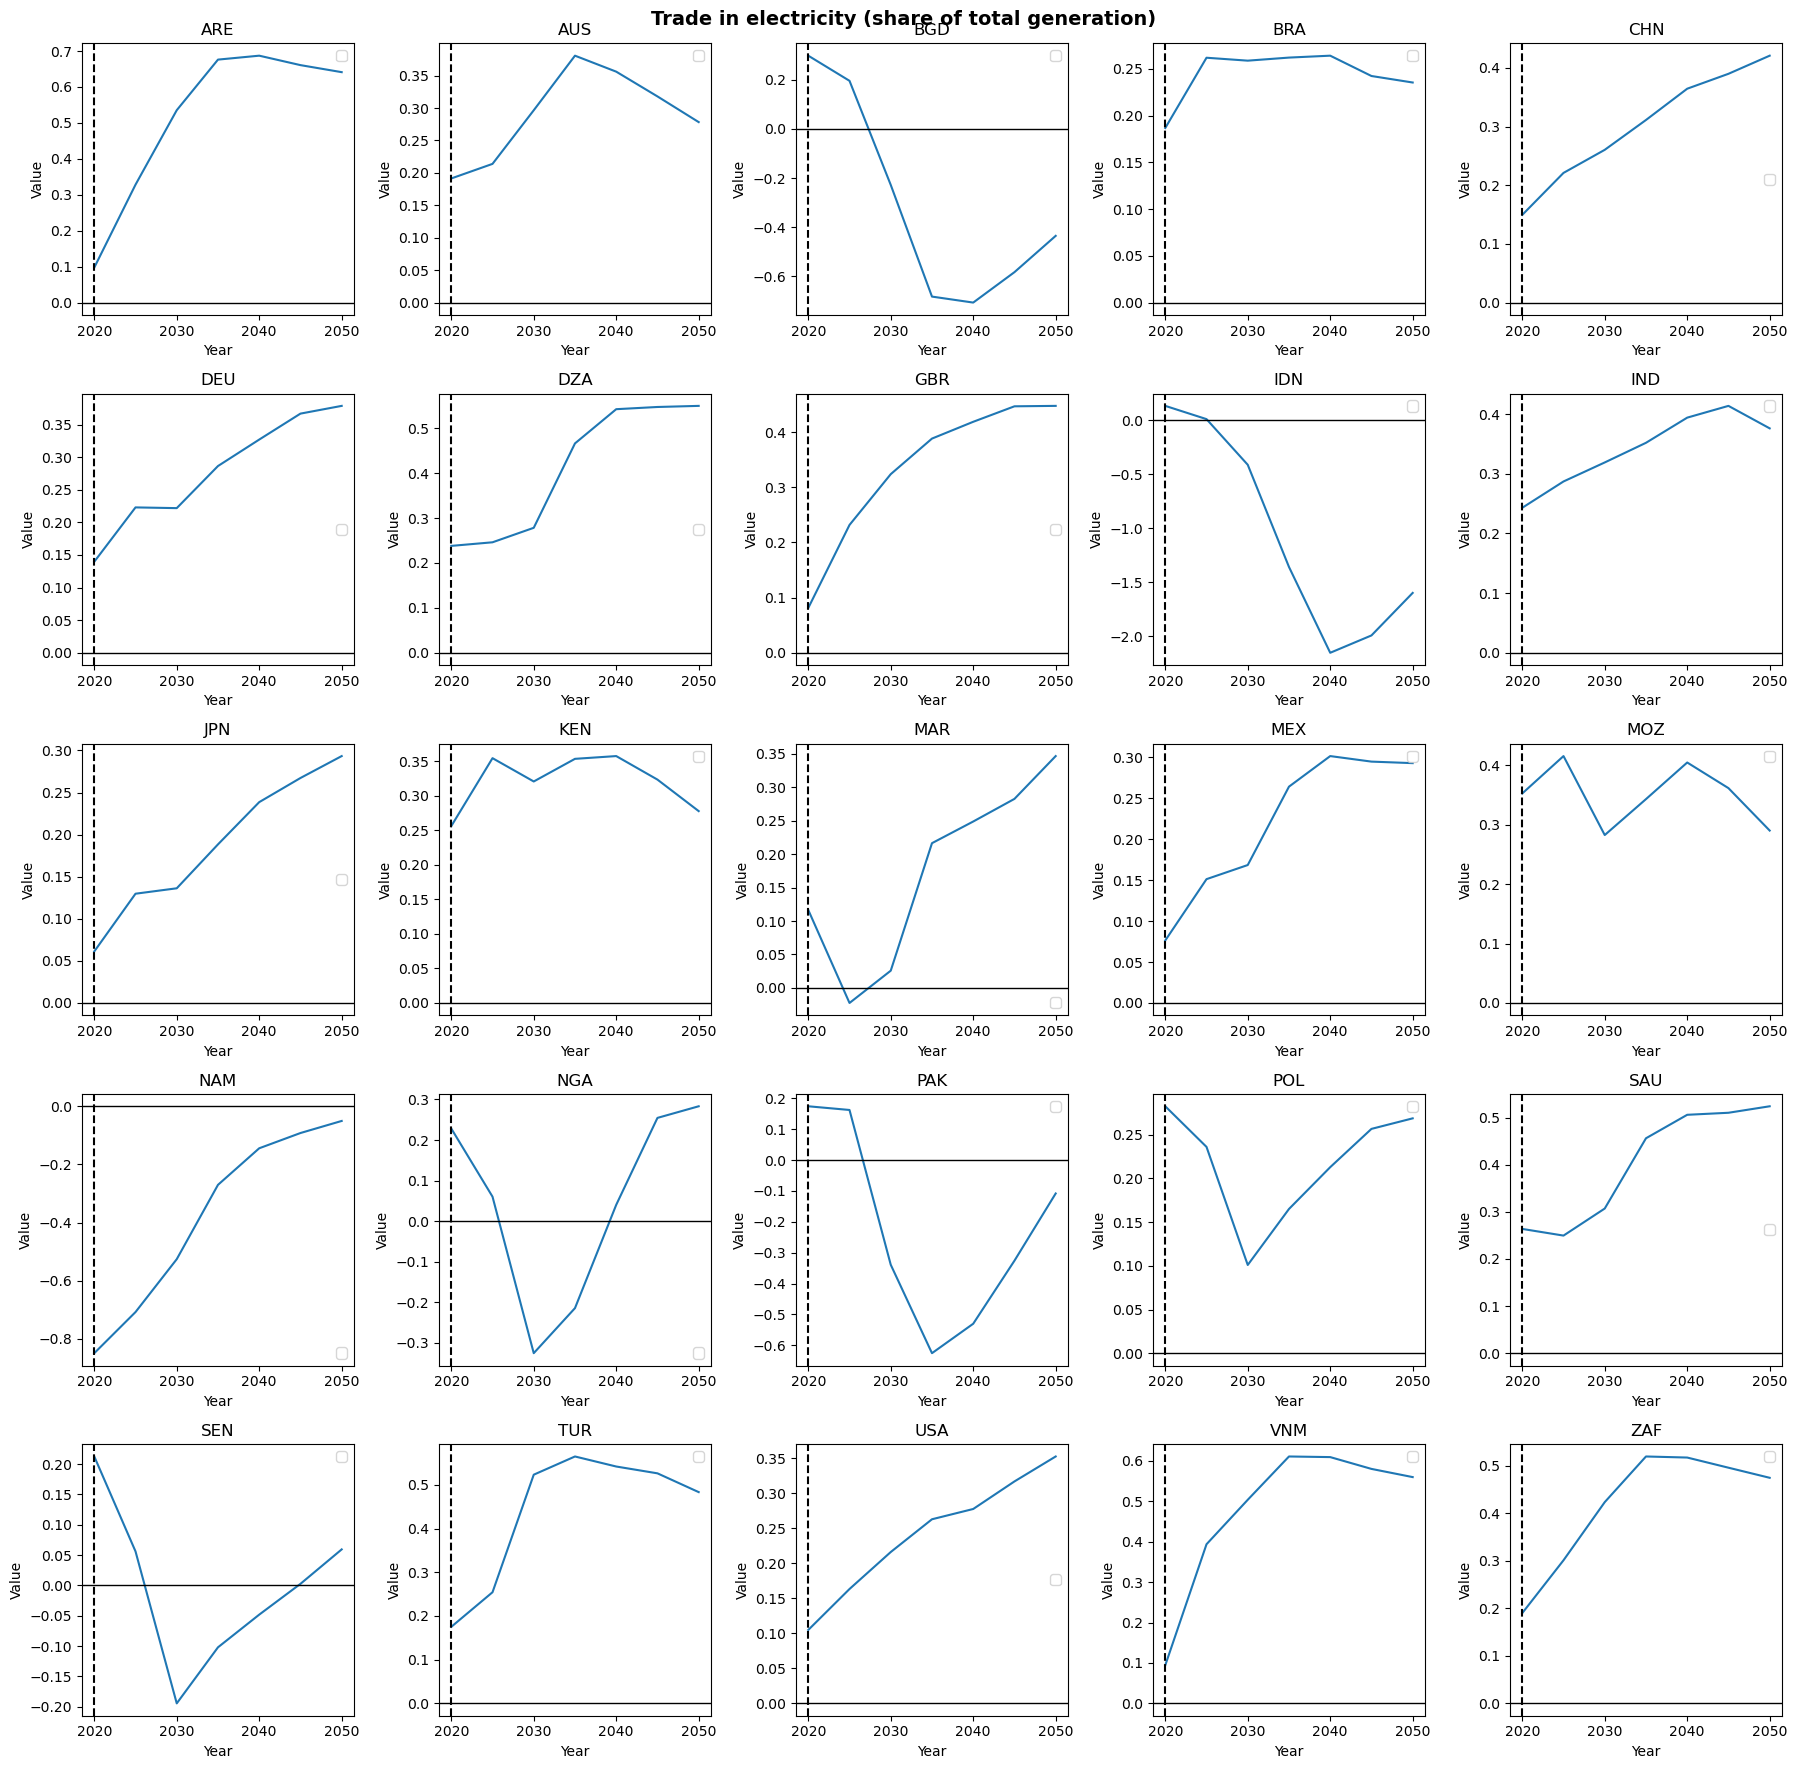

In [41]:
year_proj = [
    2020,
 2025,
 2030,
 2035,
 2040,
 2045,
 2050,
 ]

f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable='Secondary Energy|Electricity|Trade|% of total',
        year = year_proj
    ).plot(ax=ax)

    ax.axvline(x=2020, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.axhline(y=0,color='k',lw=1)

# ax.legend(ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

f.suptitle('Trade in electricity (share of total generation)',fontsize=14,fontweight='bold')

plt.tight_layout()

## Energy mix plotting

In [ ]:
transport_mix_variable = [
 'Final Energy|Transportation|Electricity',
 'Final Energy|Transportation|Gases|Biomass',
 'Final Energy|Transportation|Gases|Electricity',
 'Final Energy|Transportation|Gases|Natural Gas',
 'Final Energy|Transportation|Hydrogen',
 'Final Energy|Transportation|Liquids|Biomass',
 'Final Energy|Transportation|Liquids|Coal',
 'Final Energy|Transportation|Liquids|Electricity',
 'Final Energy|Transportation|Liquids|Oil'
 ]

In [ ]:
transport_color_map = {
    'Final Energy|Transportation|Electricity': "#ffd92f",
    'Final Energy|Transportation|Gases|Biomass': "#28a441",
    'Final Energy|Transportation|Gases|Electricity': "#500e6f",
    'Final Energy|Transportation|Gases|Natural Gas': "#77797c",
    'Final Energy|Transportation|Hydrogen': "#5fa2cf",
    'Final Energy|Transportation|Liquids|Biomass': '#4ef670',
    # 'Final Energy|Transportation|Liquids|Coal': "#9F9F9F",
    'Final Energy|Transportation|Liquids|Electricity': "#941dcc",
    'Final Energy|Transportation|Liquids|Oil': "#202020"
}

hatch = {
    'v0.0__REMIND-MAgPIE 2.1-4.3__DeepElec_SSP2_ HighRE_Budg900' : '//'
}

transport_legend_key = []
for color in transport_color_map.keys():
    transport_legend_key.append(mpatches.Patch(label=color,color=transport_color_map[color]))


pyam.run_control().update({"color": {"variable": transport_color_map}, "hatch" : {"scenario" : hatch}})

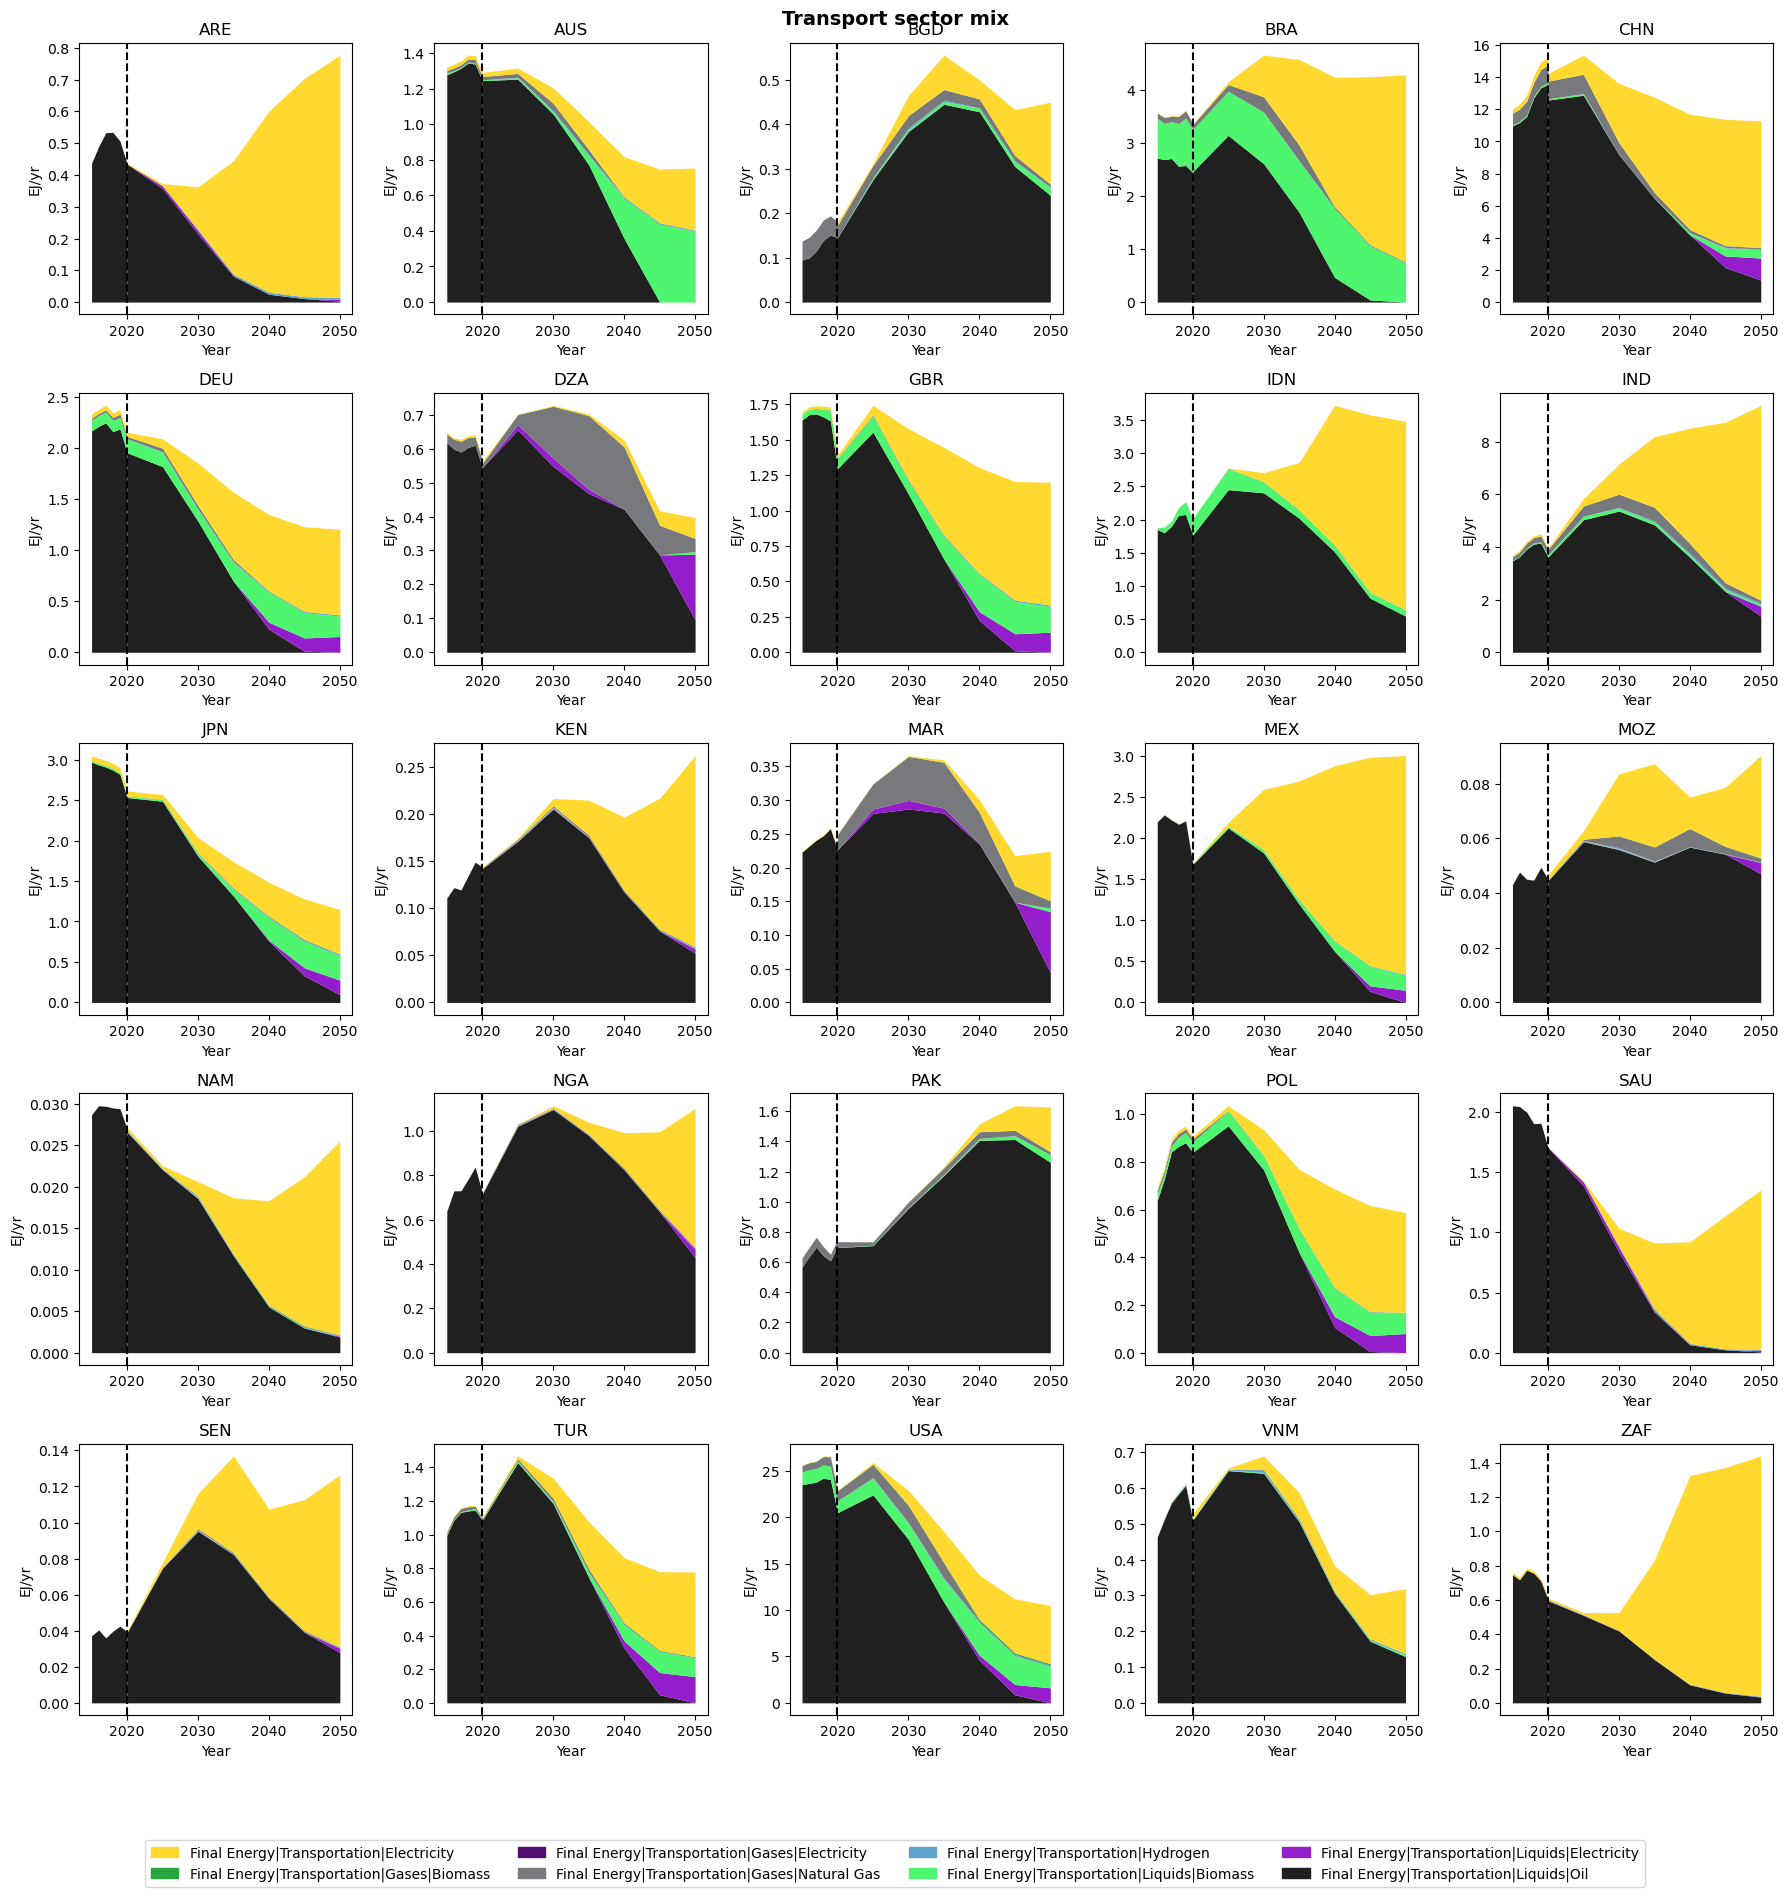

In [ ]:
year_proj = [
    2020,
 2025,
 2030,
 2035,
 2040,
 2045,
 2050,
 ]

f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable=transport_mix_variable,
        year = year_proj
    ).plot.stack(ax=ax,)

    hist_data_iea.filter(
        region=IKEA_ISOS[count],
        variable=transport_mix_variable,
        year=[2015, 2016, 2017, 2018, 2019, 2020]
    ).plot.stack(ax=ax)

    ax.axvline(x=2020, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.legend().remove()

# ax.legend(ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

f.suptitle('Transport sector mix',fontsize=14,fontweight='bold')
f.legend(transport_legend_key,[l.get_label() for l in transport_legend_key],ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

plt.tight_layout()

In [ ]:
industry_mix_variable = [
 'Final Energy|Industry|Electricity',
 'Final Energy|Industry|Gases|Biomass',
 'Final Energy|Industry|Gases|Electricity',
 'Final Energy|Industry|Gases|Natural Gas',
 'Final Energy|Industry|Hydrogen',
 'Final Energy|Industry|Heat',
 'Final Energy|Industry|Liquids|Biomass',
 'Final Energy|Industry|Liquids|Coal',
 'Final Energy|Industry|Liquids|Electricity',
 'Final Energy|Industry|Liquids|Oil',
 'Final Energy|Industry|Solids|Biomass',
 'Final Energy|Industry|Solids|Coal'
 ]

industry_color_map = {
    'Final Energy|Industry|Electricity': "#ffd92f",
    'Final Energy|Industry|Gases|Biomass': "#28a441",
    'Final Energy|Industry|Liquids|Biomass': '#4ef670',
    'Final Energy|Industry|Solids|Biomass': "#1a5726",
    'Final Energy|Industry|Gases|Electricity': "#500e6f",
    'Final Energy|Industry|Liquids|Electricity': "#941dcc",
    'Final Energy|Industry|Hydrogen': "#5fa2cf",
    'Final Energy|Industry|Solids|Coal': "#000000",
    'Final Energy|Industry|Liquids|Oil': "#323232",
    'Final Energy|Industry|Gases|Natural Gas': "#77797c",
    'Final Energy|Industry|Heat': "#cb5202",
}

hatch = {
    'v0.0__REMIND-MAgPIE 2.1-4.3__DeepElec_SSP2_ HighRE_Budg900' : '//'
}

industry_legend_key = []
for color in industry_color_map.keys():
    industry_legend_key.append(mpatches.Patch(label=color,color=industry_color_map[color]))


pyam.run_control().update({"color": {"variable": industry_color_map}, "hatch" : {"scenario" : hatch}})

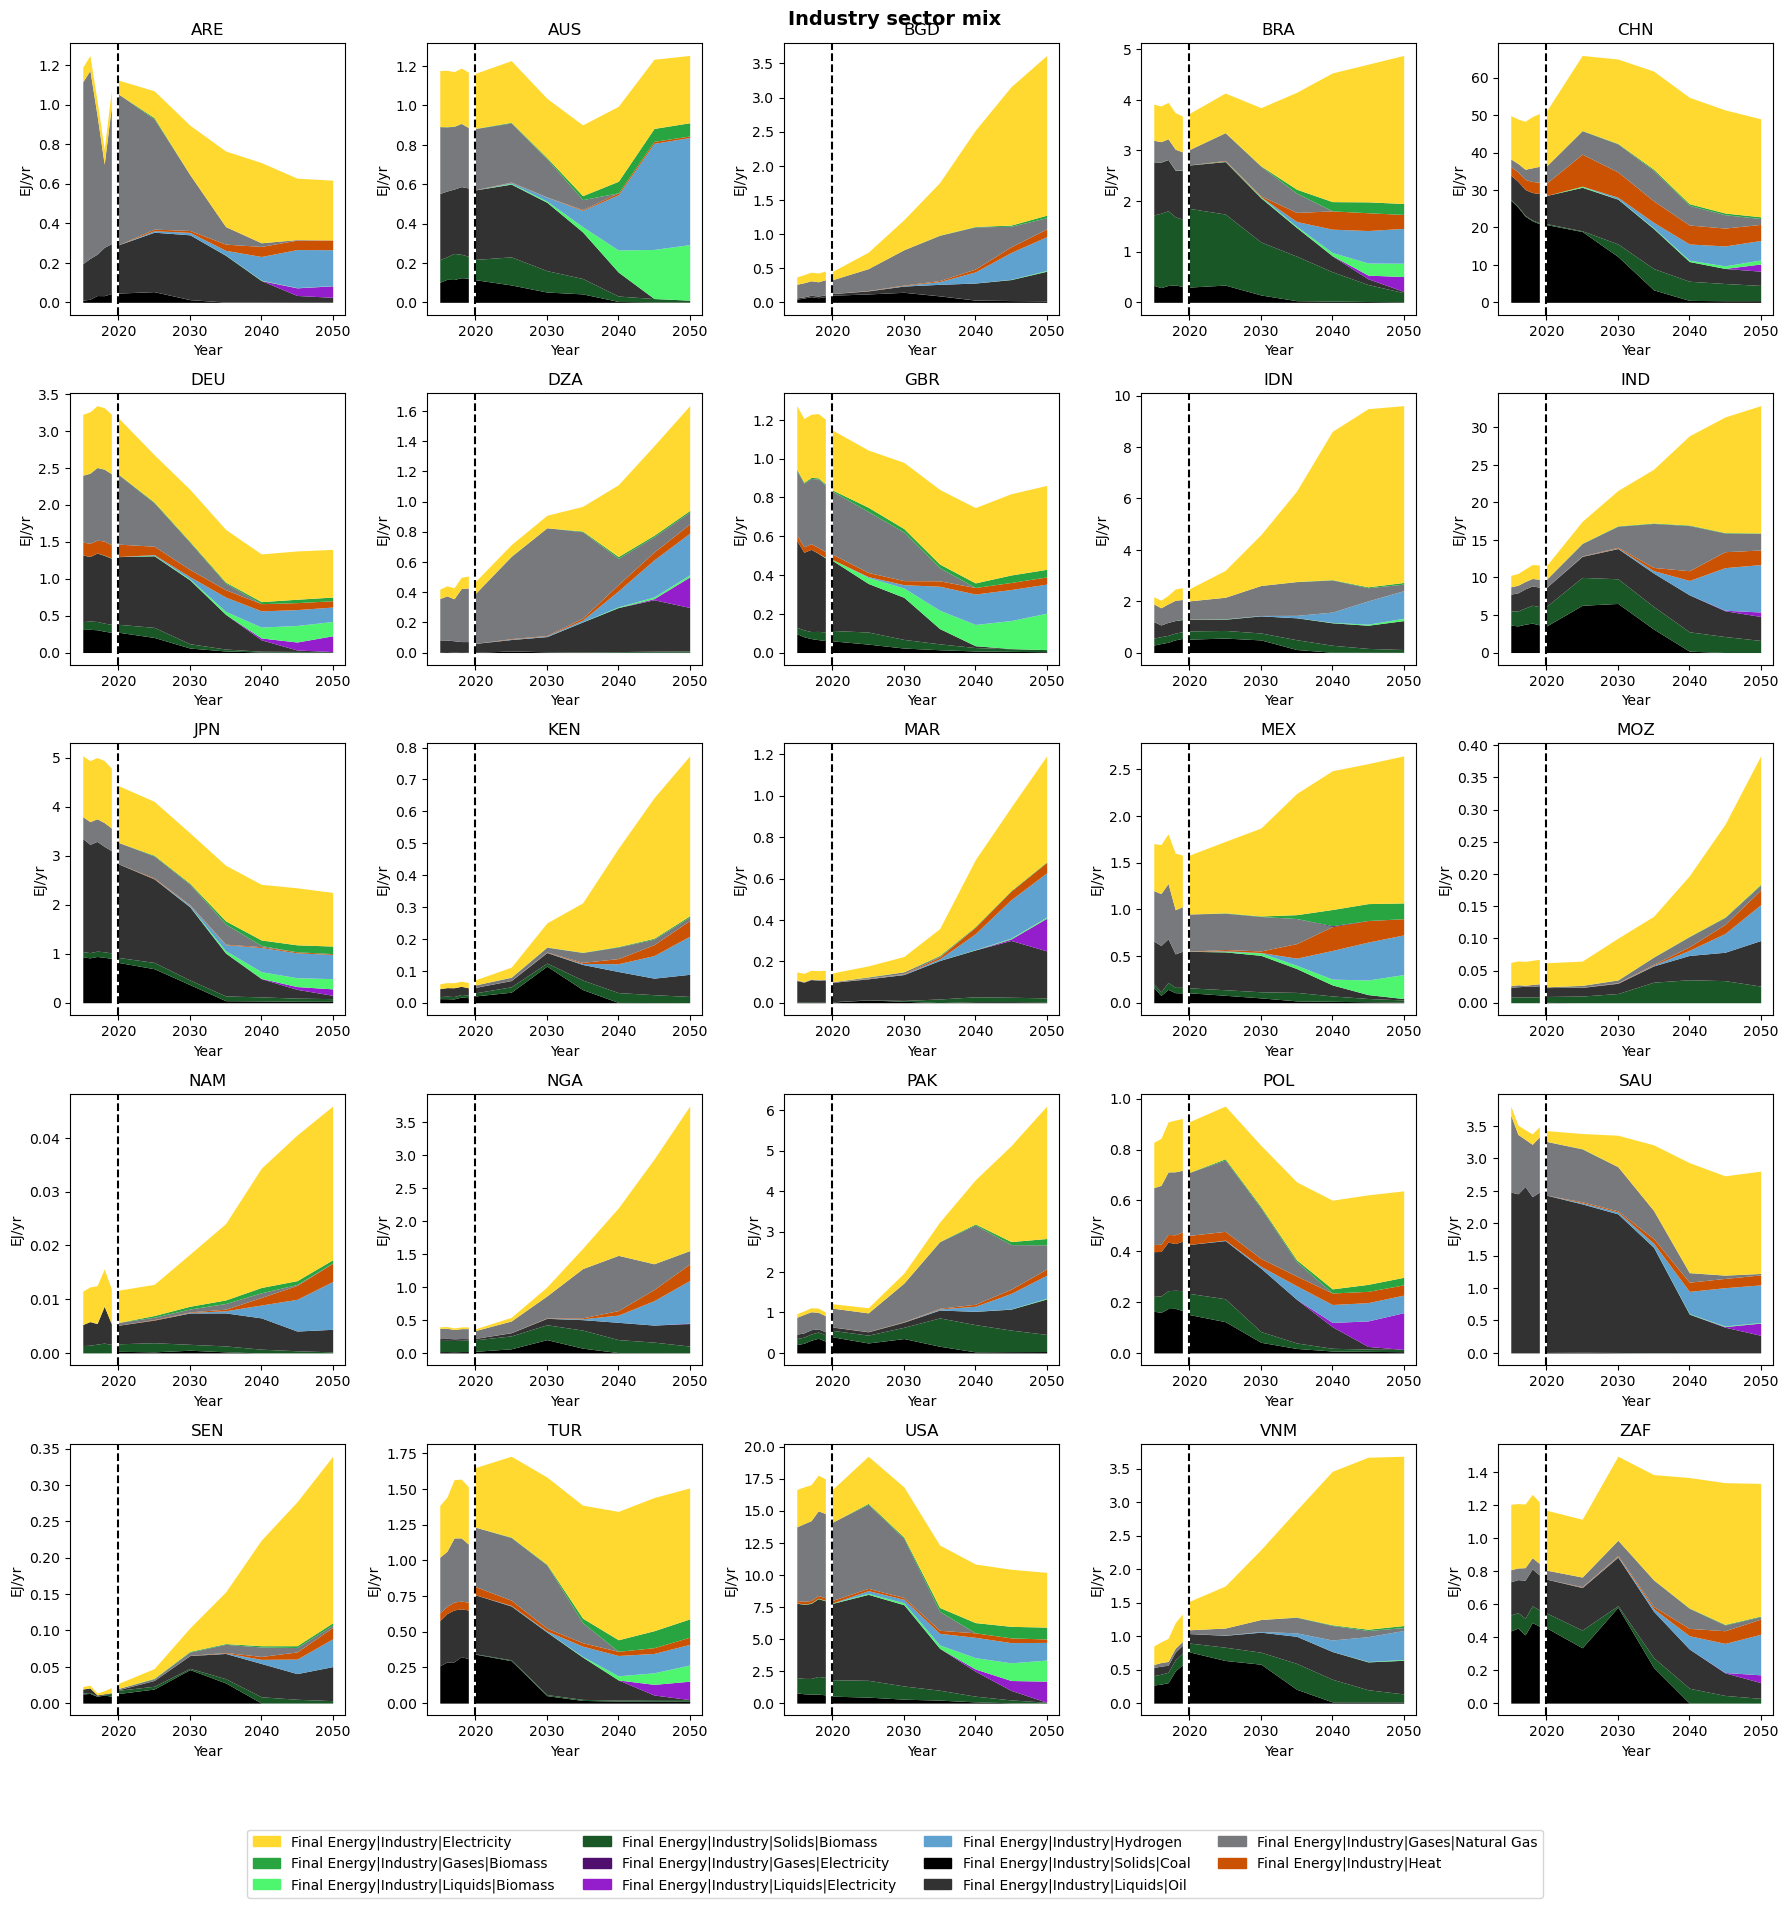

In [ ]:
year_proj = [2020,
 2025,
 2030,
 2035,
 2040,
 2045,
 2050,
#  2055,
#  2060,
#  2065,
#  2070,
#  2075,
#  2080,
#  2085,
#  2090,
#  2095,
#  2100
 ]

f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable=industry_mix_variable,
        year = year_proj
    ).plot.stack(ax=ax,)

    hist_data_iea.filter(
        region=IKEA_ISOS[count],
        variable=industry_mix_variable,
        year=[2015, 2016, 2017, 2018, 2019]
    ).plot.stack(ax=ax)

    ax.axvline(x=2020, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.legend().remove()

# ax.legend(ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

f.suptitle('Industry sector mix',fontsize=14,fontweight='bold')
f.legend(industry_legend_key,[l.get_label() for l in industry_legend_key],ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

plt.tight_layout()

In [ ]:
buildings_mix_variable = [
 'Final Energy|Residential and Commercial|Electricity',
 'Final Energy|Residential and Commercial|Gases|Biomass',
 'Final Energy|Residential and Commercial|Gases|Electricity',
 'Final Energy|Residential and Commercial|Gases|Natural Gas',
 'Final Energy|Residential and Commercial|Hydrogen',
 'Final Energy|Residential and Commercial|Liquids|Biomass',
 'Final Energy|Residential and Commercial|Liquids|Coal',
 'Final Energy|Residential and Commercial|Liquids|Electricity',
 'Final Energy|Residential and Commercial|Liquids|Oil',
 'Final Energy|Residential and CommercialSolids|Biomass',
 'Final Energy|Residential and Commercial|Solids|Coal'
 ]


buildings_color_map = {
    'Final Energy|Residential and Commercial|Electricity': "#ffd92f",
    'Final Energy|Residential and Commercial|Gases|Biomass': "#28a441",
    'Final Energy|Residential and Commercial|Liquids|Biomass': '#4ef670',
    'Final Energy|Residential and Commercial|Solids|Biomass': "#1a5726",
    'Final Energy|Residential and Commercial|Gases|Electricity': "#500e6f",
    'Final Energy|Residential and Commercial|Liquids|Electricity': "#941dcc",
    'Final Energy|Residential and Commercial|Hydrogen': "#5fa2cf",
    'Final Energy|Residential and Commercial|Solids|Coal': "#000000",
    'Final Energy|Residential and Commercial|Liquids|Oil': "#575757",
    'Final Energy|Residential and Commercial|Gases|Natural Gas': "#b2b2b2",
    'Final Energy|Residential and Commercial|Heat': "#cb5202",
}

hatch = {
    'v0.0__REMIND-MAgPIE 2.1-4.3__DeepElec_SSP2_ HighRE_Budg900' : '//'
}

buildings_legend_key = []
for color in buildings_color_map.keys():
    buildings_legend_key.append(mpatches.Patch(label=color,color=buildings_color_map[color]))


pyam.run_control().update({"color": {"variable": buildings_color_map}, "hatch" : {"scenario" : hatch}})

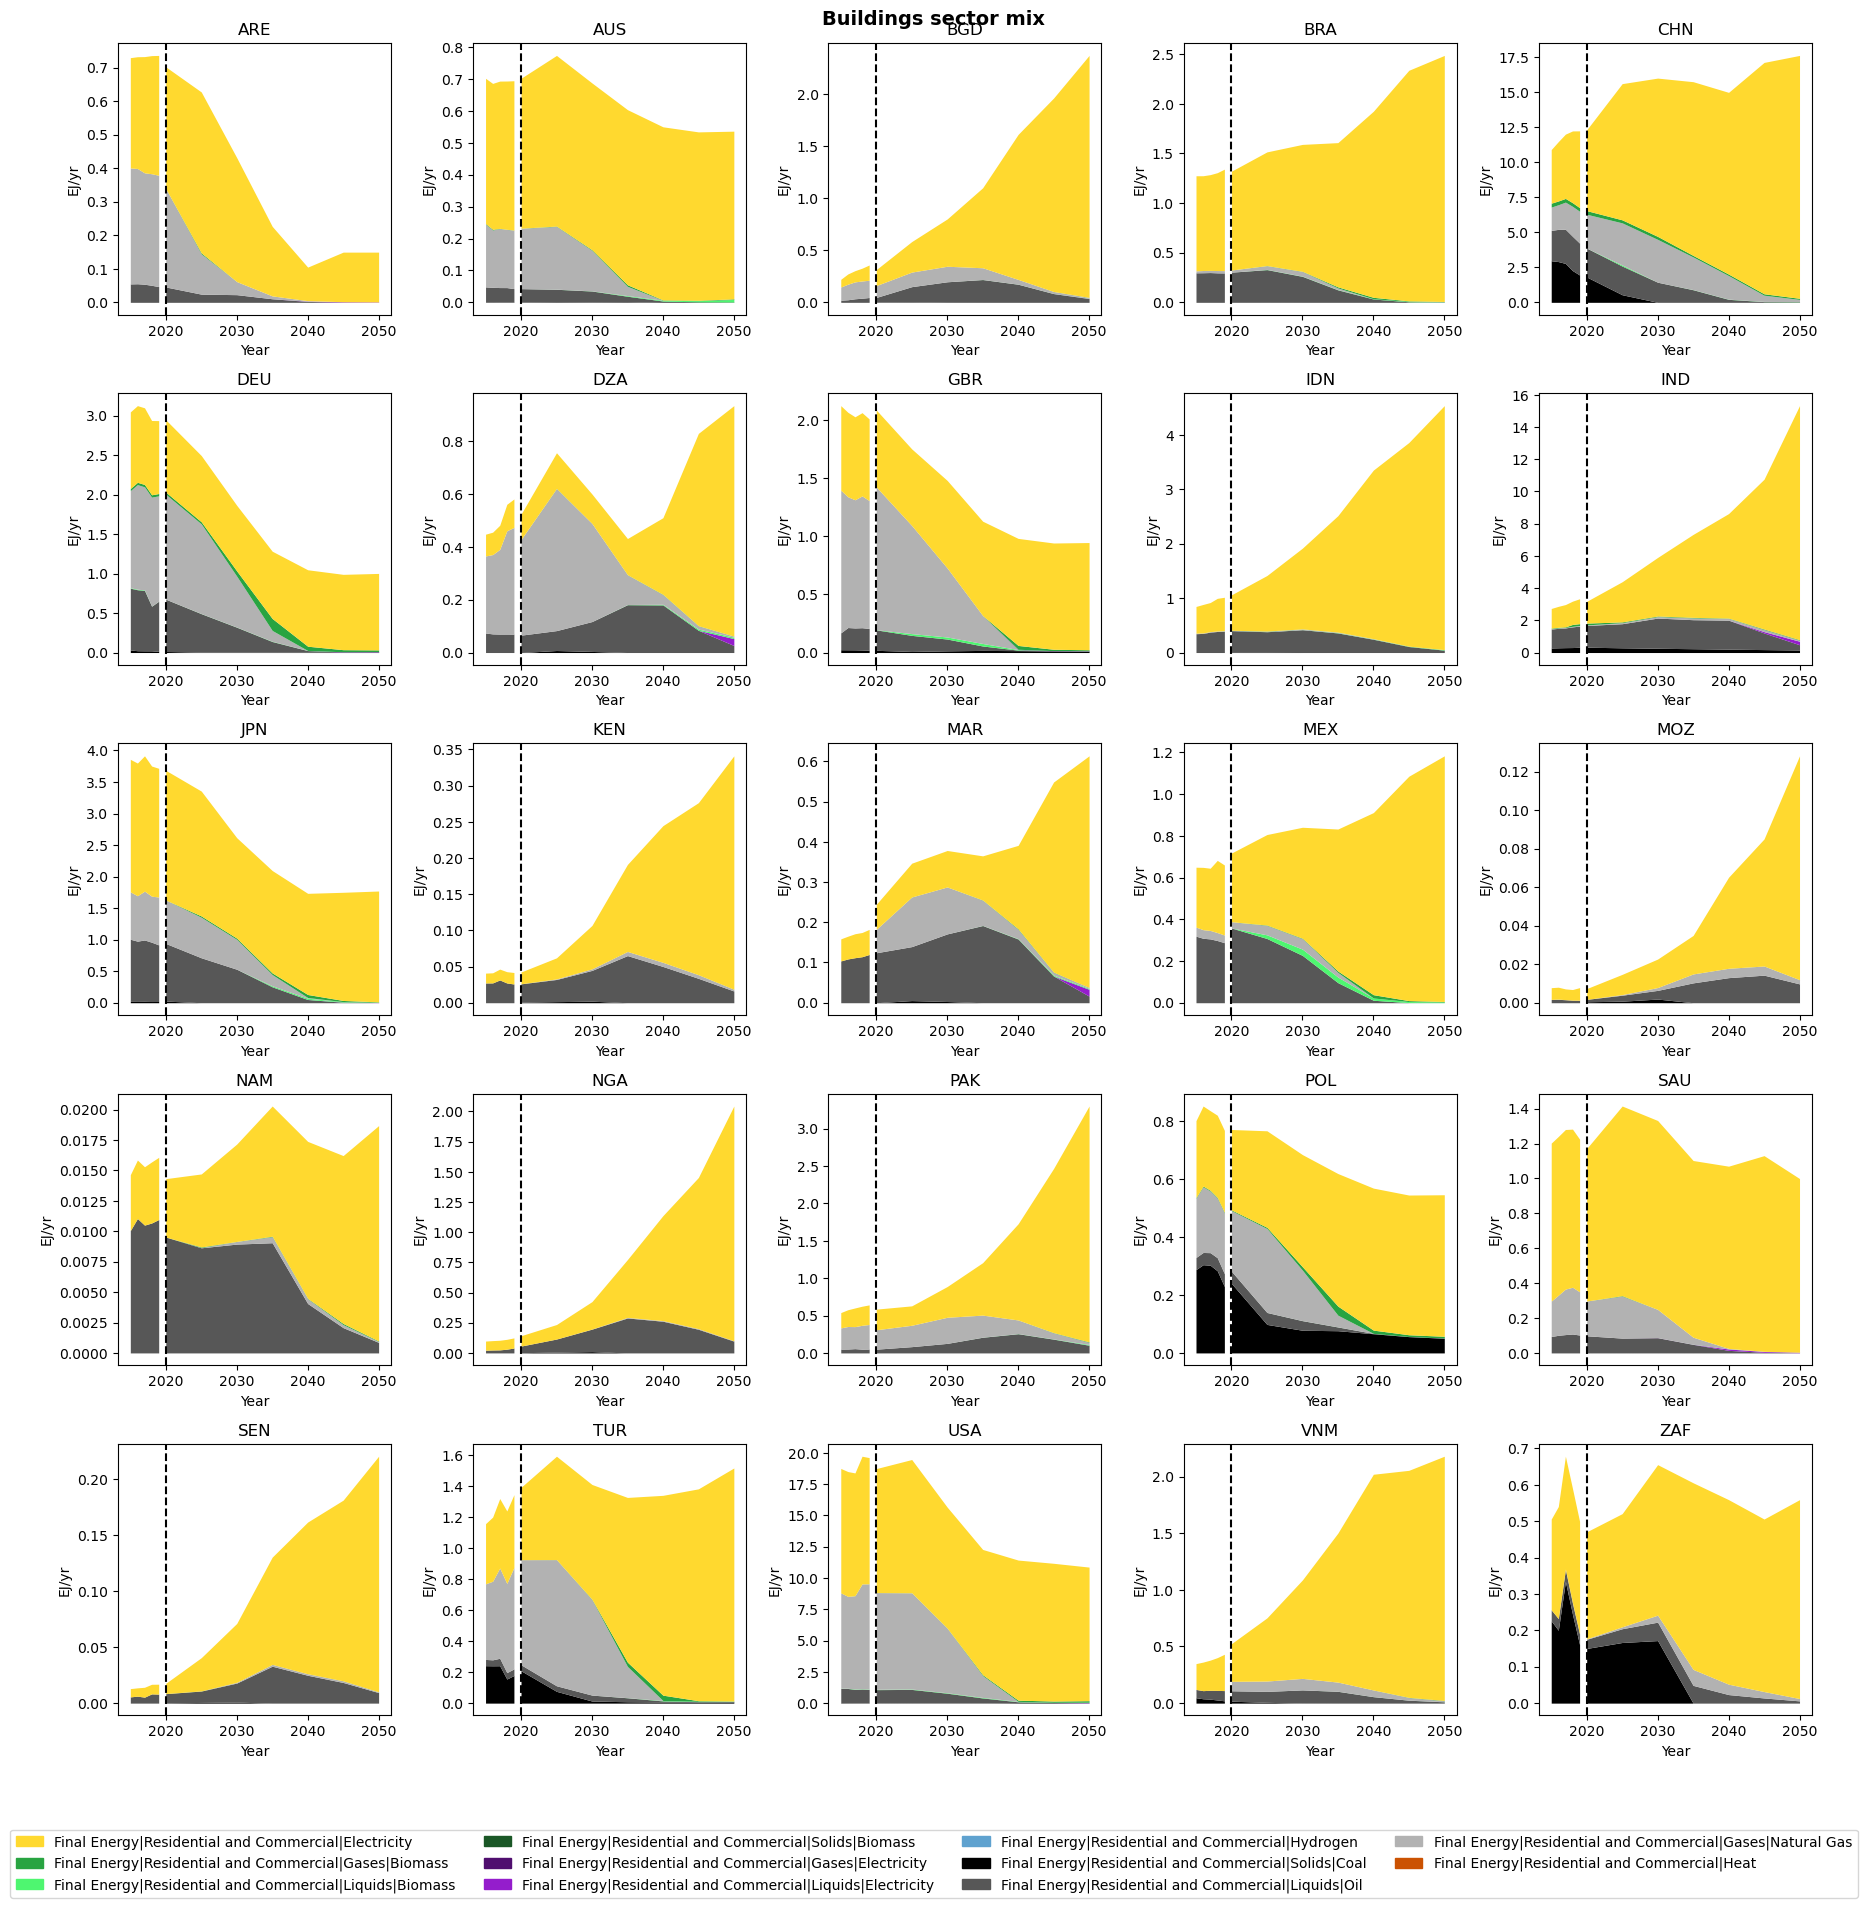

In [ ]:
year_proj = [2020,
 2025,
 2030,
 2035,
 2040,
 2045,
 2050,
#  2055,
#  2060,
#  2065,
#  2070,
#  2075,
#  2080,
#  2085,
#  2090,
#  2095,
#  2100
 ]

f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable=buildings_mix_variable,
        year = year_proj
    ).plot.stack(ax=ax,)

    hist_data_iea.filter(
        region=IKEA_ISOS[count],
        variable=buildings_mix_variable,
        year=[2015, 2016, 2017, 2018, 2019]
    ).plot.stack(ax=ax)

    ax.axvline(x=2020, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.legend().remove()

# ax.legend(ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

f.suptitle('Buildings sector mix',fontsize=14,fontweight='bold')
f.legend(buildings_legend_key,[l.get_label() for l in buildings_legend_key],ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()